# Cross-Model Analysis — Polymarket ML

**DS-GA 1003 | NYU**  
**Team:** Dhairya Dhamani, Hector Thompson Baroni, Sachin Sastri

Unified analysis across all five models trained on Polymarket prediction market data.

| Section | Topic |
|---|---|
| 0 | Setup & Data Loading |
| 1 | Overall Performance Summary (RQ1) |
| 2 | Trends Data Impact (RQ2) |
| 3 | Lifecycle Stage Analysis (RQ3) |
| 4 | Market-Level Analysis |
| 5 | Category-Level Analysis |
| 6 | Calibration Analysis |
| 7 | Error Analysis |
| 8 | Why Some Models Outperform Others |

**SVM note:** SVM was trained on a subsampled dataset (fixed lifecycle percentiles: 20/30/40/50/60/70/80%), yielding 29,219 rows vs 288,490 for the other models. Direct comparison of absolute AUC values is not fair — SVM results are shown separately where relevant.

## Section 0 — Setup & Data Loading

In [14]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    average_precision_score, roc_curve, precision_recall_curve,
)
from sklearn.calibration import calibration_curve

ROOT = Path('../')
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

# ── Paths ──────────────────────────────────────────────────────────────
DATA_CLEAN     = ROOT / 'data/polymarket_ml_dataset_clean.parquet'
DATA_TRENDS    = ROOT / 'data/polymarket_ml_dataset_with_trends_clean.parquet'

PRED_LR        = ROOT / 'models/logistic_regression/predictions/predictions.csv'
PRED_GB        = ROOT / 'models/gradient_boosting/predictions/predictions.csv'
PRED_RF        = ROOT / 'models/random_forest/predictions/test_predictions.csv'
PRED_RF_TR     = ROOT / 'models/random_forest_trends/predictions/trends_test_predictions.csv'
PRED_SVM       = ROOT / 'models/svm/predictions/predictions_no_trends_shared.csv'
PRED_SVM_TR    = ROOT / 'models/svm/predictions/predictions_with_trends.csv'

COLORS = {
    'Market Baseline': '#78909C',
    'LR':              '#E91E63',
    'LR+Trends':       '#F48FB1',
    'GB':              '#FF9800',
    'GB+Trends':       '#FFCC80',
    'RF':              '#2196F3',
    'RF+Trends':       '#4CAF50',
    'SVM':             '#9C27B0',
    'SVM+Trends':      '#CE93D8',
    'Ensemble':        '#FF5722',
}

# ── Helper functions ────────────────────────────────────────────────────
def metrics(y_true, y_proba, brier_baseline=None):
    p = np.clip(y_proba, 1e-7, 1 - 1e-7)
    b = brier_score_loss(y_true, p)
    bss = (brier_baseline - b) / brier_baseline if brier_baseline else np.nan
    return {
        'AUC-ROC':  round(roc_auc_score(y_true, p), 4),
        'PR-AUC':   round(average_precision_score(y_true, p), 4),
        'Log-loss': round(log_loss(y_true, p), 4),
        'Brier':    round(b, 4),
        'BSS':      round(bss, 4),
    }

def ece(y_true, y_proba, n_bins=10):
    frac, mean_pred = calibration_curve(y_true, y_proba, n_bins=n_bins)
    edges = np.linspace(0, 1, n_bins + 1)
    bin_weights = np.array([
        ((y_proba >= edges[i]) & (y_proba < edges[i+1])).mean()
        for i in range(n_bins)
    ])[:len(frac)]
    return round(float(np.sum(np.abs(frac - mean_pred) * bin_weights)), 4)

print('Setup complete.')

Setup complete.


In [15]:
# ── Load parquet test set ───────────────────────────────────────────────
print('Loading parquet...')
pq_full = pd.read_parquet(DATA_CLEAN)
test_pq = pq_full[pq_full['split'] == 'test'].copy()
test_pq['snapshot_timestamp'] = pd.to_datetime(test_pq['snapshot_timestamp'], utc=True)
test_pq = test_pq.sort_values(['market_id', 'snapshot_timestamp']).reset_index(drop=True)
test_pq['snap_idx'] = test_pq.groupby('market_id').cumcount()  # 0-based within-market index

print(f'Test parquet: {len(test_pq):,} rows | {test_pq["market_id"].nunique():,} markets')
print(f'YES rate: {test_pq["outcome"].mean():.3f} | Categories: {sorted(test_pq["category"].unique())}')

# Market-level metadata (one row per market)
market_meta = (
    test_pq.sort_values(['market_id', 'snapshot_timestamp'])
    .groupby('market_id')
    .agg(
        outcome=('outcome', 'first'),
        category=('category', 'first'),
        log_volume=('log_volume', 'first'),
        total_volume=('total_volume', 'first'),
        duration_days=('duration_days', 'first'),
        n_snapshots=('snapshot_timestamp', 'count'),
    )
    .reset_index()
)
print(f'Market meta: {len(market_meta):,} markets')

Loading parquet...
Test parquet: 288,490 rows | 4,174 markets
YES rate: 0.210 | Categories: ['crypto', 'entertainment', 'finance', 'geopolitics', 'other', 'politics_global', 'politics_us', 'science_tech', 'sports']
Market meta: 4,174 markets


In [16]:
# ── Load prediction CSVs ────────────────────────────────────────────────
print('Loading prediction CSVs...')
lr    = pd.read_csv(PRED_LR)
gb    = pd.read_csv(PRED_GB)
rf    = pd.read_csv(PRED_RF)
rf_tr = pd.read_csv(PRED_RF_TR)
svm   = pd.read_csv(PRED_SVM)
svm_tr= pd.read_csv(PRED_SVM_TR)

pq_key = test_pq[['market_id', 'snap_idx', 'snapshot_timestamp',
                   'pct_lifetime_elapsed', 'price_at_snapshot',
                   'category', 'days_before_close', 'outcome']]

# LR and GB: join on snapshot_timestamp directly (timestamp saved in CSV to avoid snap_idx mismatch)
lr['snapshot_timestamp'] = pd.to_datetime(lr['snapshot_timestamp'], utc=True)
gb['snapshot_timestamp'] = pd.to_datetime(gb['snapshot_timestamp'], utc=True)
lr_j = lr.merge(pq_key, on=['market_id', 'snapshot_timestamp'], how='inner', suffixes=('_lr',''))
gb_j = gb.merge(pq_key, on=['market_id', 'snapshot_timestamp'], how='inner', suffixes=('_gb',''))

# RF/RF-Trends: join on market_id + snapshot_timestamp
rf['snapshot_timestamp']    = pd.to_datetime(rf['snapshot_timestamp'], utc=True)
rf_tr['snapshot_timestamp'] = pd.to_datetime(rf_tr['snapshot_timestamp'], utc=True)
rf_j    = rf.merge(pq_key, on=['market_id', 'snapshot_timestamp'], how='inner', suffixes=('','_pq'))
rf_tr_j = rf_tr.merge(pq_key, on=['market_id', 'snapshot_timestamp'], how='inner', suffixes=('','_pq'))

# Canonical proba columns
lr_j['proba']    = lr_j['pred_prob_base']
gb_j['proba']    = gb_j['pred_prob_base']
rf_j['proba']    = rf_j['proba_full_calibrated']
rf_tr_j['proba'] = rf_tr_j['proba_trends_calibrated']
svm['proba']     = svm['pred_proba_nt']
svm_tr['proba']  = svm_tr['pred_proba_wt']

# Market baseline (price_at_snapshot)
BASELINE = np.clip(test_pq['price_at_snapshot'].values, 1e-6, 1-1e-6)
Y_TEST   = test_pq['outcome'].values
baseline_brier = brier_score_loss(Y_TEST, BASELINE)

print(f'LR joined:        {len(lr_j):,} rows')
print(f'GB joined:        {len(gb_j):,} rows')
print(f'RF joined:        {len(rf_j):,} rows')
print(f'RF+Trends joined: {len(rf_tr_j):,} rows')
print(f'SVM:              {len(svm):,} rows | {svm["market_id"].nunique():,} markets')
print(f'Market baseline Brier: {baseline_brier:.4f}')

Loading prediction CSVs...
LR joined:        288,490 rows
GB joined:        288,490 rows
RF joined:        288,490 rows
RF+Trends joined: 288,490 rows
SVM:              29,064 rows | 4,152 markets
Market baseline Brier: 0.1004


---
## Section 1 — Overall Performance Summary (RQ1)

**RQ1:** Can ML models outperform prediction market probabilities in forecasting outcomes?

Metrics:
- **AUC-ROC** — discrimination ability (threshold-free)
- **PR-AUC** — precision-recall; more informative than AUC-ROC under class imbalance (77.6% NO)
- **Log-loss** — probabilistic accuracy; penalises confident wrong predictions
- **Brier Score** — mean squared probability error (lower = better)
- **Brier Skill Score (BSS)** = `(Brier_baseline − Brier_model) / Brier_baseline` — % improvement over market baseline; normalises for task difficulty

In [17]:
# ── Snapshot-level metrics — all base + trends variants ─────────────────
snap_results = {}
snap_results['Market Baseline'] = metrics(Y_TEST, BASELINE)
snap_results['Market Baseline']['BSS'] = 0.0

for name, df, col in [
    ('LR',         lr_j,    'pred_prob_base'),
    ('LR+Trends',  lr_j,    'pred_prob_trends'),
    ('GB',         gb_j,    'pred_prob_base'),
    ('GB+Trends',  gb_j,    'pred_prob_trends'),
    ('RF',         rf_j,    'proba_full_calibrated'),
    ('RF+Trends',  rf_tr_j, 'proba_trends_calibrated'),
]:
    snap_results[name] = metrics(df['outcome'].values, df[col].values, baseline_brier)

# Also update canonical proba columns for downstream use
lr_j['proba']       = lr_j['pred_prob_base']
lr_j['proba_tr']    = lr_j['pred_prob_trends']
gb_j['proba']       = gb_j['pred_prob_base']
gb_j['proba_tr']    = gb_j['pred_prob_trends']
rf_j['proba']       = rf_j['proba_full_calibrated']
rf_tr_j['proba']    = rf_tr_j['proba_trends_calibrated']

# SVM: separate subset (29K rows, fixed percentile snapshots — not directly comparable)
svm_baseline   = np.clip(svm['baseline'].values, 1e-6, 1-1e-6)
svm_brier_base = brier_score_loss(svm['outcome'].values, svm_baseline)
svm_results = {
    'SVM Baseline': metrics(svm['outcome'].values,    svm_baseline),
    'SVM':          metrics(svm['outcome'].values,    svm['pred_proba_nt'].values, svm_brier_base),
    'SVM+Trends':   metrics(svm_tr['outcome'].values, svm_tr['pred_proba_wt'].values, svm_brier_base),
}
svm_results['SVM Baseline']['BSS'] = 0.0

results_df = pd.DataFrame(snap_results).T
svm_df     = pd.DataFrame(svm_results).T

print('=== Snapshot-level models (288,490 test snapshots) ===')
print(results_df[['AUC-ROC','PR-AUC','Log-loss','Brier','BSS']].to_string())
print()
print('=== SVM (29,219 subsampled snapshots — not directly comparable) ===')
print(svm_df[['AUC-ROC','PR-AUC','Log-loss','Brier','BSS']].to_string())

=== Snapshot-level models (288,490 test snapshots) ===
                 AUC-ROC  PR-AUC  Log-loss   Brier     BSS
Market Baseline   0.8890  0.7440    0.3278  0.1004  0.0000
LR                0.8874  0.7101    0.3317  0.0980  0.0243
LR+Trends         0.8868  0.7096    0.3301  0.0980  0.0243
GB                0.9000  0.7445    0.3073  0.0941  0.0630
GB+Trends         0.9019  0.7525    0.3043  0.0930  0.0738
RF                0.9018  0.7527    0.3027  0.0922  0.0820
RF+Trends         0.9034  0.7598    0.3011  0.0914  0.0902

=== SVM (29,219 subsampled snapshots — not directly comparable) ===
              AUC-ROC  PR-AUC  Log-loss   Brier     BSS
SVM Baseline   0.9402  0.8229    0.2196  0.0655  0.0000
SVM            0.9398  0.8126    0.2226  0.0651  0.0059
SVM+Trends     0.9405  0.8138    0.2217  0.0649  0.0092


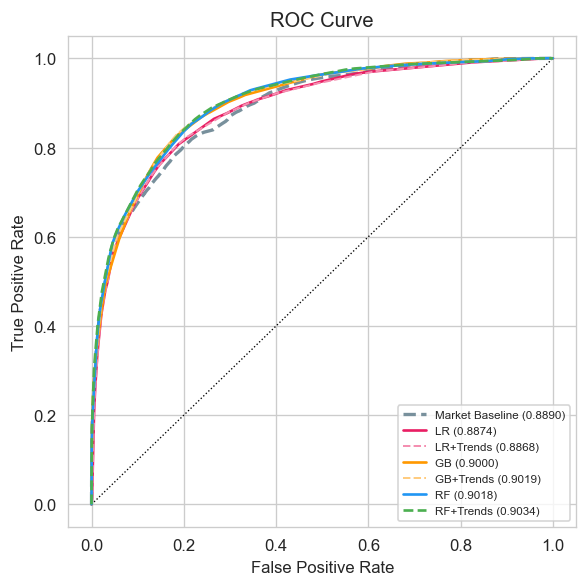

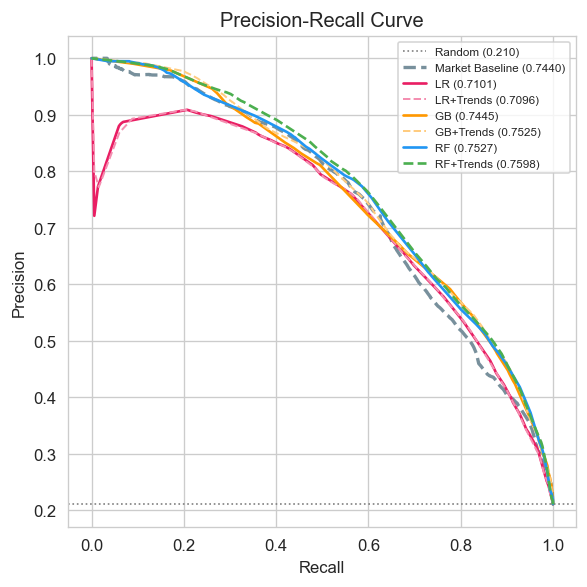

In [28]:
# ── ROC + PR curves — saved as separate square figures ─────────────────
plot_items = [
    ('Market Baseline', Y_TEST,             BASELINE,                               '--', 2.0),
    ('LR',              lr_j['outcome'],    lr_j['pred_prob_base'],                 '-',  1.6),
    ('LR+Trends',       lr_j['outcome'],    lr_j['pred_prob_trends'],               '--', 1.2),
    ('GB',              gb_j['outcome'],    gb_j['pred_prob_base'],                 '-',  1.6),
    ('GB+Trends',       gb_j['outcome'],    gb_j['pred_prob_trends'],               '--', 1.2),
    ('RF',              rf_j['outcome'],    rf_j['proba_full_calibrated'],          '-',  1.6),
    ('RF+Trends',       rf_tr_j['outcome'], rf_tr_j['proba_trends_calibrated'],     '--', 1.6),
]

# ── ROC curve ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], 'k:', lw=0.8)
for name, y, p, ls, lw in plot_items:
    fpr, tpr, _ = roc_curve(y, p)
    auc = roc_auc_score(y, p)
    ax.plot(fpr, tpr, color=COLORS[name], ls=ls, lw=lw, label=f'{name} ({auc:.4f})')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

# ── PR curve ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
yes_rate = Y_TEST.mean()
ax.axhline(yes_rate, color='gray', ls=':', lw=1, label=f'Random ({yes_rate:.3f})')
for name, y, p, ls, lw in plot_items:
    prec, rec, _ = precision_recall_curve(y, p)
    pr_auc = average_precision_score(y, p)
    ax.plot(rec, prec, color=COLORS[name], ls=ls, lw=lw, label=f'{name} ({pr_auc:.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150)
plt.show()

---
## Section 2 — Trends Data Impact (RQ2)

**RQ2:** Do Google Trends features add predictive value?

Three models have base + trends variants: LR, GB, RF. We compare them directly and ask:
- How much does each metric change when trends are added?
- Does the gain depend on whether trends data was actually available for that snapshot?
- Which market categories benefit most from trends features?

In [19]:
# ── Trends delta table ──────────────────────────────────────────────────
trend_pairs = [
    ('LR',  lr_j['outcome'].values,    lr_j['pred_prob_base'].values,    lr_j['pred_prob_trends'].values),
    ('GB',  gb_j['outcome'].values,    gb_j['pred_prob_base'].values,    gb_j['pred_prob_trends'].values),
    ('RF',  rf_tr_j['outcome'].values, rf_tr_j['proba_full'].values,     rf_tr_j['proba_trends_calibrated'].values),
]

delta_rows = []
for model, y, p_base, p_trends in trend_pairs:
    m_base   = metrics(y, p_base,   baseline_brier)
    m_trends = metrics(y, p_trends, baseline_brier)
    delta_rows.append({
        'Model':       model,
        'AUC (base)':  m_base['AUC-ROC'],
        'AUC (trends)':m_trends['AUC-ROC'],
        'ΔAUC':        round(m_trends['AUC-ROC']  - m_base['AUC-ROC'],  4),
        'ΔLog-loss':   round(m_trends['Log-loss'] - m_base['Log-loss'], 4),
        'ΔBrier':      round(m_trends['Brier']    - m_base['Brier'],    4),
        'ΔBSS':        round(m_trends['BSS']      - m_base['BSS'],      4),
    })

delta_df = pd.DataFrame(delta_rows)
print('Trends delta (negative ΔLog-loss / ΔBrier = improvement):')
print(delta_df.to_string(index=False))

Trends delta (negative ΔLog-loss / ΔBrier = improvement):
Model  AUC (base)  AUC (trends)    ΔAUC  ΔLog-loss  ΔBrier   ΔBSS
   LR      0.8874        0.8868 -0.0006    -0.0016  0.0000 0.0000
   GB      0.9000        0.9019  0.0019    -0.0030 -0.0011 0.0108
   RF      0.9023        0.9034  0.0011    -0.0470 -0.0174 0.1736


In [20]:
# ── Trends data coverage and conditional AUC ─────────────────────────────
# Load trends parquet just to get has_trend_data column
print('Loading trends parquet for coverage check...')
pq_trends = pd.read_parquet(DATA_TRENDS, columns=['market_id','snapshot_timestamp','has_trend_data','split'])
pq_trends = pq_trends[pq_trends['split'] == 'test']
pq_trends['snapshot_timestamp'] = pd.to_datetime(pq_trends['snapshot_timestamp'], utc=True)

# Join RF+Trends predictions with has_trend_data
rf_tr_cov = rf_tr_j.merge(
    pq_trends[['market_id','snapshot_timestamp','has_trend_data']],
    on=['market_id','snapshot_timestamp'], how='left'
)

coverage = rf_tr_cov['has_trend_data'].mean()
print(f'Trends data coverage: {coverage:.1%} of test snapshots have trend data')

y       = rf_tr_cov['outcome'].values
p_full  = rf_tr_cov['proba_full'].values
p_trend = rf_tr_cov['proba_trends_calibrated'].values
has_td  = rf_tr_cov['has_trend_data'].fillna(False).astype(bool).values

print('\nConditional AUC — RF Full vs RF+Trends, split by trends data availability:')
print(f'  Rows WITH trends data ({has_td.sum():,}):')
if has_td.sum() > 100 and y[has_td].mean() > 0:
    print(f'    RF Full:    {roc_auc_score(y[has_td], p_full[has_td]):.4f}')
    print(f'    RF+Trends:  {roc_auc_score(y[has_td], p_trend[has_td]):.4f}')
print(f'  Rows WITHOUT trends data ({(~has_td).sum():,}):')
if (~has_td).sum() > 100 and y[~has_td].mean() > 0:
    print(f'    RF Full:    {roc_auc_score(y[~has_td], p_full[~has_td]):.4f}')
    print(f'    RF+Trends:  {roc_auc_score(y[~has_td], p_trend[~has_td]):.4f}')

Loading trends parquet for coverage check...
Trends data coverage: 99.5% of test snapshots have trend data

Conditional AUC — RF Full vs RF+Trends, split by trends data availability:
  Rows WITH trends data (287,126):
    RF Full:    0.9023
    RF+Trends:  0.9035
  Rows WITHOUT trends data (1,364):
    RF Full:    0.8915
    RF+Trends:  0.7392


Trends lift per category (LR base -> LR+Trends):
       Category  Snapshots  AUC (base)  AUC (trends)    ΔAUC
         crypto      24586      0.9029        0.9057  0.0028
   science_tech      15530      0.8849        0.8853  0.0004
        finance      25093      0.9171        0.9171 -0.0001
    geopolitics      16578      0.9355        0.9348 -0.0007
  entertainment      37027      0.9198        0.9190 -0.0008
    politics_us      52699      0.9044        0.9035 -0.0009
politics_global      22591      0.9077        0.9062 -0.0014
         sports      93022      0.8427        0.8412 -0.0015

Trends lift per category (GB base -> GB+Trends):
       Category  Snapshots  AUC (base)  AUC (trends)    ΔAUC
    geopolitics      16578      0.9229        0.9354  0.0125
        finance      25093      0.8977        0.9039  0.0062
         sports      93022      0.8696        0.8727  0.0031
    politics_us      52699      0.9155        0.9159  0.0005
  entertainment      37027      0.9292        0

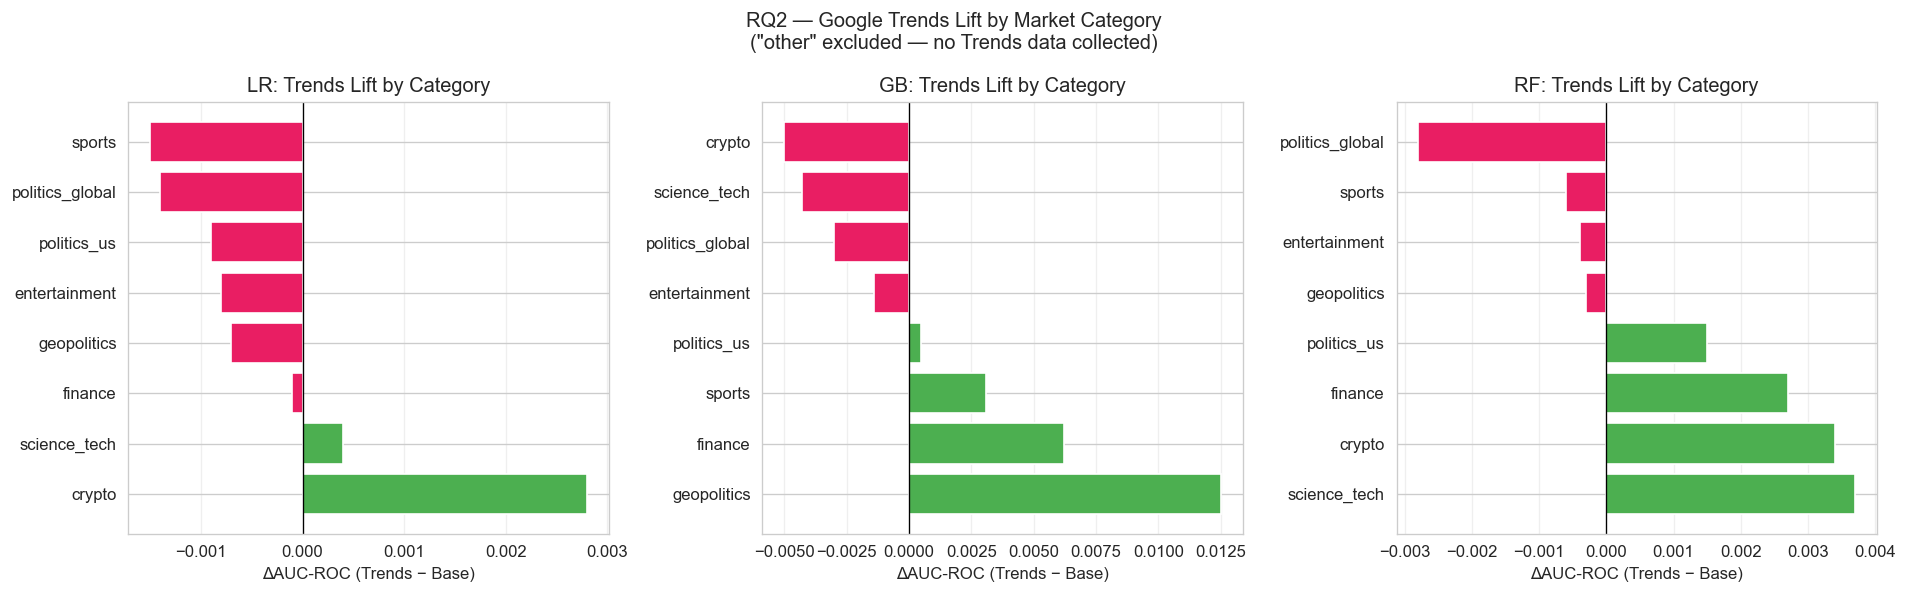

In [21]:
# ── Trends lift by category — LR, GB, RF ───────────────────────────────
# 'other' excluded: no Trends data collected there (trend_value=0, has_trend_data=False).

model_configs = [
    ('LR',  lr_j,    'pred_prob_base',        'pred_prob_trends'),
    ('GB',  gb_j,    'pred_prob_base',         'pred_prob_trends'),
    ('RF',  rf_tr_j, 'proba_full',             'proba_trends_calibrated'),
]

all_cat_dfs = {}
for model_name, df, col_base, col_trends in model_configs:
    rows = []
    for cat, grp in df.groupby('category'):
        if cat == 'other':
            continue
        if grp['outcome'].nunique() < 2 or len(grp) < 50:
            continue
        auc_base   = roc_auc_score(grp['outcome'], grp[col_base])
        auc_trends = roc_auc_score(grp['outcome'], grp[col_trends])
        rows.append({
            'Category':     cat,
            'Snapshots':    len(grp),
            'AUC (base)':   round(auc_base,   4),
            'AUC (trends)': round(auc_trends, 4),
            'ΔAUC':         round(auc_trends - auc_base, 4),
        })
    cat_df = pd.DataFrame(rows).sort_values('ΔAUC', ascending=False)
    all_cat_dfs[model_name] = cat_df
    print(f'Trends lift per category ({model_name} base -> {model_name}+Trends):')
    print(cat_df.to_string(index=False))
    print()

# ── 3-panel bar chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, (model_name, cat_df) in zip(axes, all_cat_dfs.items()):
    colors = ['#4CAF50' if d >= 0 else '#E91E63' for d in cat_df['ΔAUC']]
    ax.barh(cat_df['Category'], cat_df['ΔAUC'], color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('ΔAUC-ROC (Trends − Base)')
    ax.set_title(f'{model_name}: Trends Lift by Category')
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('RQ2 — Google Trends Lift by Market Category\n("other" excluded — no Trends data collected)',
             fontsize=12)
plt.tight_layout()
plt.savefig('trends_lift_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Lifecycle Stage Analysis (RQ3)

**RQ3:** At which stage of a market's lifecycle do external signals provide the most value?

Lifecycle buckets based on `pct_lifetime_elapsed`:
- **Early (0–33%):** Market just started. Price is near 0.5, little information. Features and trends should matter most here.
- **Mid (33–67%):** Market in progress. Price has started to move but hasn't converged.
- **Late (67–100%):** Market near resolution. Price has converged strongly toward 0 or 1. Baseline is very strong here.

**Hypothesis:** The gap between model AUC and market baseline should be largest in Early, shrinking toward Late as price becomes the dominant signal.

In [22]:
# ── Build snap_frame (used here and in Section 7) ────────────────────────
snap_frame = rf_j[['market_id','snapshot_timestamp','outcome','pct_lifetime_elapsed',
                    'price_at_snapshot','days_before_close','category']].copy()
snap_frame = snap_frame.merge(
    rf_j[['market_id','snapshot_timestamp','proba']].rename(columns={'proba':'p_rf'}),
    on=['market_id','snapshot_timestamp']
).merge(
    rf_tr_j[['market_id','snapshot_timestamp','proba']].rename(columns={'proba':'p_rf_tr'}),
    on=['market_id','snapshot_timestamp'], how='left'
).merge(
    lr_j[['market_id','snapshot_timestamp','proba','proba_tr']]
    .rename(columns={'proba':'p_lr','proba_tr':'p_lr_tr'})
    [['market_id','snapshot_timestamp','p_lr','p_lr_tr']],
    on=['market_id','snapshot_timestamp'], how='left'
).merge(
    gb_j[['market_id','snapshot_timestamp','proba','proba_tr']]
    .rename(columns={'proba':'p_gb','proba_tr':'p_gb_tr'})
    [['market_id','snapshot_timestamp','p_gb','p_gb_tr']],
    on=['market_id','snapshot_timestamp'], how='left'
)
snap_frame['p_baseline'] = np.clip(snap_frame['price_at_snapshot'], 1e-6, 1-1e-6)

MODEL_COLS = [
    ('p_lr',    'LR'),
    ('p_lr_tr', 'LR+Trends'),
    ('p_gb',    'GB'),
    ('p_gb_tr', 'GB+Trends'),
    ('p_rf',    'RF'),
    ('p_rf_tr', 'RF+Trends'),
]

# ── Option A: AUC by days_before_close bucket ────────────────────────────
def assign_dbc_bucket(d):
    if d > 60:  return 'Far (>60d)'
    if d > 30:  return 'Mid (30–60d)'
    return 'Near (14–30d)'

DBC_LABELS = ['Far (>60d)', 'Mid (30–60d)', 'Near (14–30d)']
snap_frame['dbc_bucket'] = pd.Categorical(
    snap_frame['days_before_close'].apply(assign_dbc_bucket),
    categories=DBC_LABELS, ordered=True
)

dbc_rows = []
for bucket in DBC_LABELS:
    grp = snap_frame[snap_frame['dbc_bucket'] == bucket]
    if grp['outcome'].nunique() < 2:
        continue
    y = grp['outcome'].values
    row = {'Stage': bucket, 'Snapshots': len(grp),
           'Baseline': round(roc_auc_score(y, grp['p_baseline']), 4)}
    for col, label in MODEL_COLS:
        valid = grp[col].notna()
        if valid.sum() > 100 and y[valid.values].sum() > 0:
            row[label] = round(roc_auc_score(y[valid.values], grp.loc[valid, col]), 4)
        else:
            row[label] = np.nan
    dbc_rows.append(row)

dbc_df = pd.DataFrame(dbc_rows)
print('Option A — AUC by days_before_close:')
print(dbc_df.to_string(index=False))

# ── Option B: rolling AUC over pct_lifetime_elapsed ──────────────────────
N_BINS      = 25
bin_edges   = np.linspace(0, 1, N_BINS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

snap_frame['plc_bin'] = pd.cut(snap_frame['pct_lifetime_elapsed'], bins=bin_edges,
                                labels=False, include_lowest=True)

roll_rows = []
for b in range(N_BINS):
    grp = snap_frame[snap_frame['plc_bin'] == b]
    if len(grp) < 300 or grp['outcome'].nunique() < 2:
        continue
    y = grp['outcome'].values
    row = {'center': bin_centers[b], 'n': len(grp),
           'Baseline': roc_auc_score(y, grp['p_baseline'])}
    for col, label in MODEL_COLS:
        valid = grp[col].notna()
        if valid.sum() > 100 and y[valid.values].sum() > 0:
            row[label] = roc_auc_score(y[valid.values], grp.loc[valid, col])
        else:
            row[label] = np.nan
    roll_rows.append(row)

roll_df = pd.DataFrame(roll_rows)
print(f'\nOption B — {len(roll_df)} bins with sufficient data')
print(roll_df[['center', 'n', 'Baseline', 'LR', 'GB', 'RF']].round(4).to_string(index=False))

Option A — AUC by days_before_close:
        Stage  Snapshots  Baseline     LR  LR+Trends     GB  GB+Trends     RF  RF+Trends
   Far (>60d)     195075    0.8785 0.8756     0.8748 0.8977     0.8985 0.8963     0.8991
 Mid (30–60d)      53282    0.9020 0.9037     0.9039 0.9019     0.9048 0.9052     0.9054
Near (14–30d)      40133    0.9169 0.9172     0.9165 0.9092     0.9139 0.9223     0.9197

Option B — 24 bins with sufficient data
 center     n  Baseline     LR     GB     RF
   0.02   631    0.9397 0.9384 0.9606 0.9658
   0.06 13762    0.9383 0.9264 0.9450 0.9393
   0.10 20135    0.9132 0.9043 0.9237 0.9185
   0.14 20572    0.9074 0.9013 0.9115 0.9111
   0.18 19940    0.8826 0.8792 0.9031 0.9042
   0.22 19338    0.8670 0.8660 0.8900 0.8938
   0.26 18719    0.8643 0.8636 0.8828 0.8847
   0.30 18085    0.8695 0.8707 0.8851 0.8887
   0.34 17658    0.8710 0.8741 0.8875 0.8949
   0.38 17162    0.8734 0.8755 0.8880 0.8931
   0.42 16491    0.8784 0.8794 0.8904 0.8922
   0.46 16129    0.8847 0.

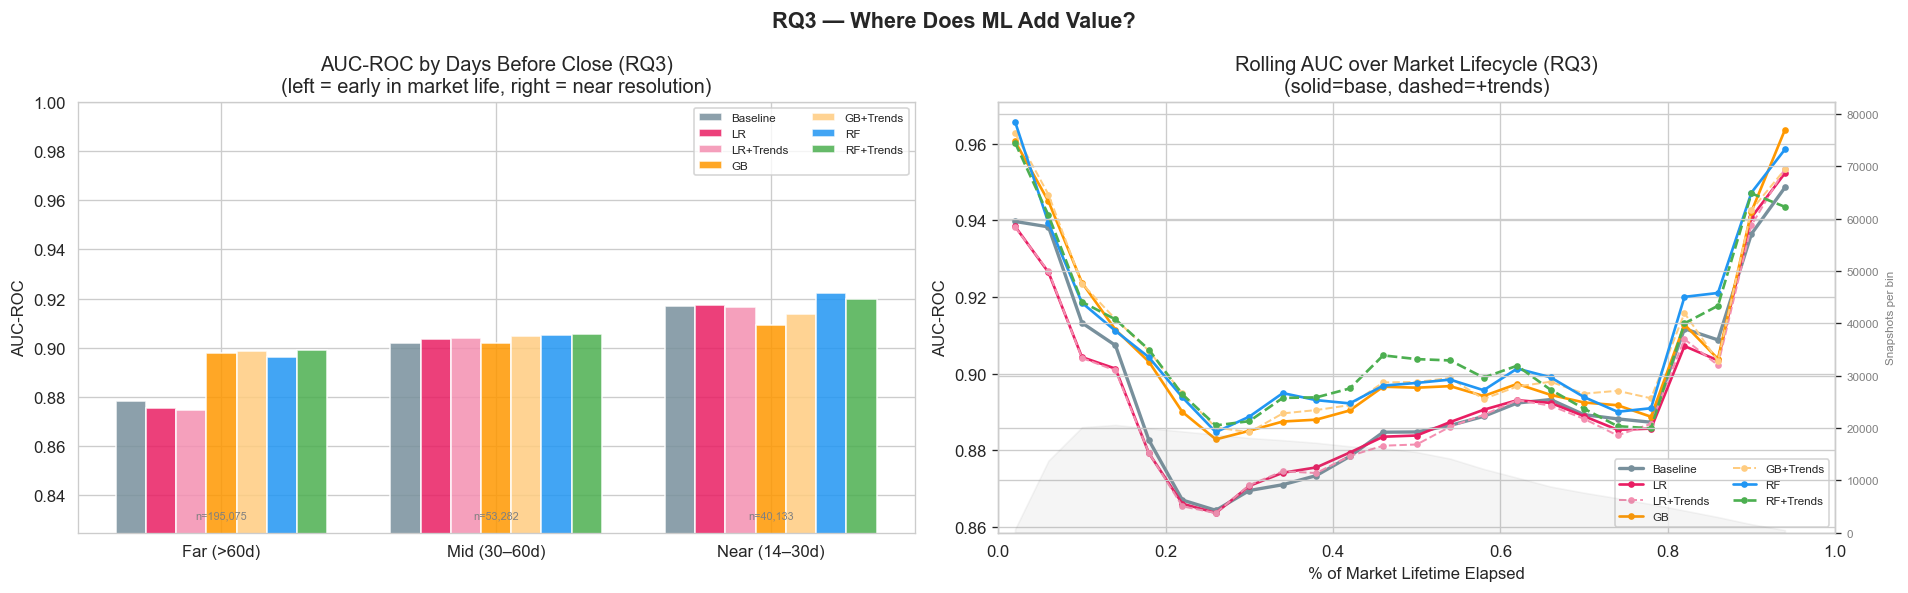

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

all_model_cols = ['Baseline', 'LR', 'LR+Trends', 'GB', 'GB+Trends', 'RF', 'RF+Trends']
all_colors     = [COLORS['Market Baseline'], COLORS['LR'], COLORS['LR+Trends'],
                  COLORS['GB'], COLORS['GB+Trends'], COLORS['RF'], COLORS['RF+Trends']]

# ── Left: Option A — bar chart by days_before_close ──────────────────────
ax = axes[0]
x = np.arange(len(dbc_df))
w = 0.11
for i, (col, color) in enumerate(zip(all_model_cols, all_colors)):
    if col in dbc_df.columns:
        ax.bar(x + (i - 3) * w, dbc_df[col], w, label=col, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(dbc_df['Stage'])
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC by Days Before Close (RQ3)\n(left = early in market life, right = near resolution)')
ax.legend(fontsize=7, ncol=2)
min_auc = dbc_df[all_model_cols].min().min()
ax.set_ylim(max(0.5, min_auc - 0.05), 1.0)
for i, row in dbc_df.iterrows():
    ax.text(i, ax.get_ylim()[0] + 0.005, f"n={row['Snapshots']:,}",
            ha='center', va='bottom', fontsize=6.5, color='gray')

# ── Right: Option B — rolling AUC line over pct_lifetime_elapsed ─────────
ax = axes[1]
line_models = [
    ('Baseline',  COLORS['Market Baseline'], '-',  2.0),
    ('LR',        COLORS['LR'],              '-',  1.6),
    ('LR+Trends', COLORS['LR+Trends'],       '--', 1.2),
    ('GB',        COLORS['GB'],              '-',  1.6),
    ('GB+Trends', COLORS['GB+Trends'],       '--', 1.2),
    ('RF',        COLORS['RF'],              '-',  1.6),
    ('RF+Trends', COLORS['RF+Trends'],       '--', 1.6),
]
for col, color, ls, lw in line_models:
    if col in roll_df.columns:
        valid = roll_df[col].notna()
        ax.plot(roll_df.loc[valid, 'center'], roll_df.loc[valid, col],
                color=color, ls=ls, lw=lw, marker='o', ms=3, label=col)
ax.set_xlabel('% of Market Lifetime Elapsed')
ax.set_ylabel('AUC-ROC')
ax.set_title('Rolling AUC over Market Lifecycle (RQ3)\n(solid=base, dashed=+trends)')
ax.legend(fontsize=7, ncol=2)
ax.set_xlim(0, 1)

# Grey shading shows where data is sparse
ax2 = ax.twinx()
ax2.fill_between(roll_df['center'], roll_df['n'], alpha=0.08, color='gray')
ax2.set_ylabel('Snapshots per bin', fontsize=7, color='gray')
ax2.tick_params(axis='y', labelcolor='gray', labelsize=7)
ax2.set_ylim(0, roll_df['n'].max() * 4)

plt.suptitle('RQ3 — Where Does ML Add Value?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lifecycle_auc.png', dpi=150, bbox_inches='tight')
plt.show()

AUC by per-market lifecycle stage (Far=early in life, Near=close to resolution):
         Stage  Snapshots  Baseline     LR  LR+Trends     GB  GB+Trends     RF  RF+Trends
   Far (0-33%)     137054    0.8910 0.8867     0.8865 0.9048     0.9069 0.9054     0.9064
  Mid (33-67%)     119722    0.8830 0.8838     0.8825 0.8936     0.8950 0.8963     0.8997
Near (67-100%)      31714    0.8981 0.8962     0.8959 0.8998     0.9024 0.9028     0.8990

Delta vs Baseline (model AUC - baseline AUC):
         Stage      LR  LR+Trends     GB  GB+Trends     RF  RF+Trends
   Far (0-33%) -0.0043    -0.0045 0.0138     0.0159 0.0144     0.0154
  Mid (33-67%)  0.0008    -0.0005 0.0106     0.0120 0.0133     0.0167
Near (67-100%) -0.0019    -0.0022 0.0017     0.0043 0.0047     0.0009


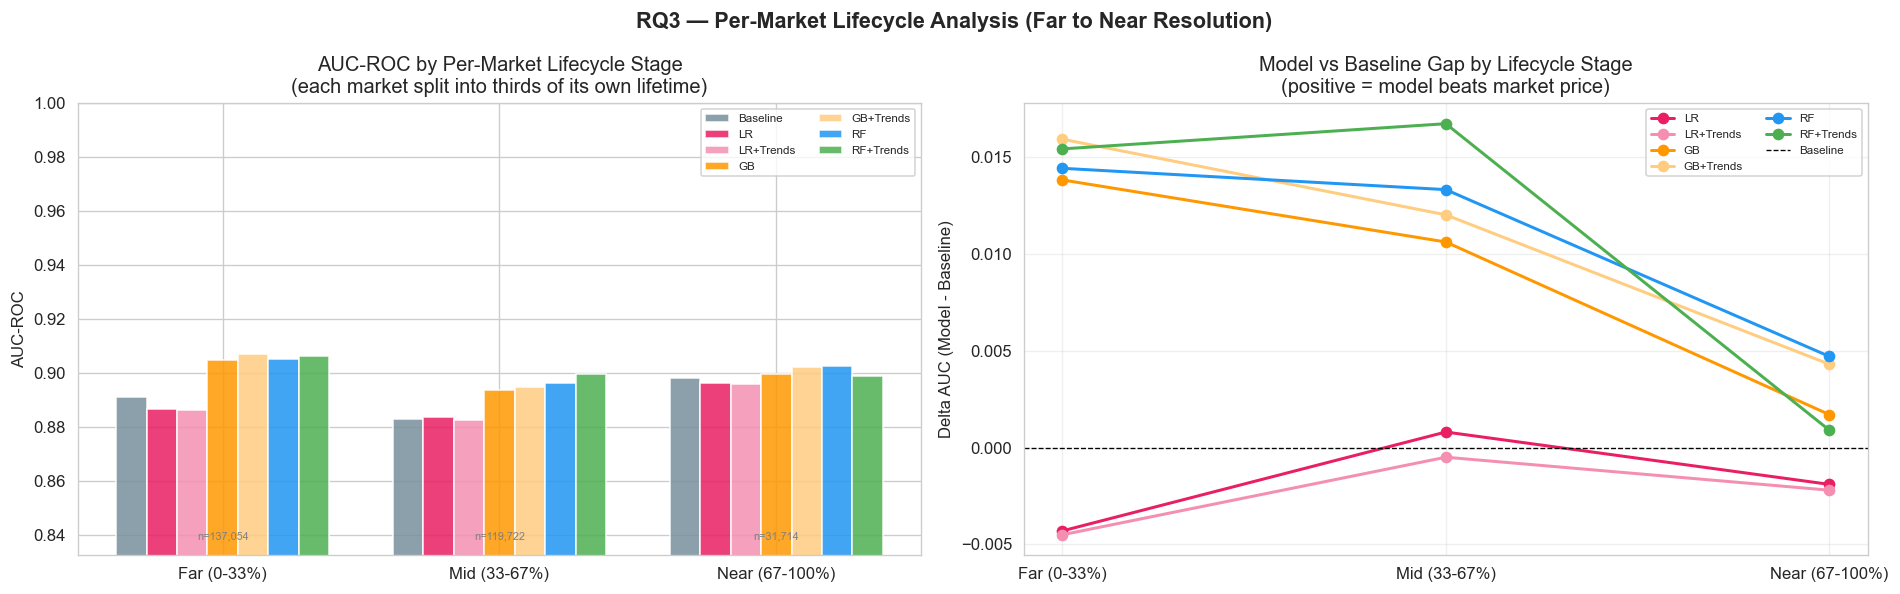

In [25]:
# ── Per-market lifecycle buckets (Far/Mid/Near thirds) ──────────────────
# Each market's snapshots are divided into thirds relative to its OWN lifetime.
# pct_lifetime_elapsed: 0=just opened, 1=at resolution.
# Far  (0-33%)  = early in market life, far from resolution
# Mid  (33-67%) = middle of market life
# Near (67-100%)= late in market life, close to resolution

def assign_plc_bucket(p):
    if p < 1/3:  return 'Far (0-33%)'
    if p < 2/3:  return 'Mid (33-67%)'
    return 'Near (67-100%)'

PLC_LABELS = ['Far (0-33%)', 'Mid (33-67%)', 'Near (67-100%)']
snap_frame['plc_bucket'] = pd.Categorical(
    snap_frame['pct_lifetime_elapsed'].apply(assign_plc_bucket),
    categories=PLC_LABELS, ordered=True
)

plc_rows = []
for bucket in PLC_LABELS:
    grp = snap_frame[snap_frame['plc_bucket'] == bucket]
    if grp['outcome'].nunique() < 2:
        continue
    y = grp['outcome'].values
    row = {'Stage': bucket, 'Snapshots': len(grp),
           'Baseline': round(roc_auc_score(y, grp['p_baseline']), 4)}
    for col, label in MODEL_COLS:
        valid = grp[col].notna()
        if valid.sum() > 100 and y[valid.values].sum() > 0:
            row[label] = round(roc_auc_score(y[valid.values], grp.loc[valid, col]), 4)
        else:
            row[label] = np.nan
    plc_rows.append(row)

plc_df = pd.DataFrame(plc_rows)
print('AUC by per-market lifecycle stage (Far=early in life, Near=close to resolution):')
print(plc_df.to_string(index=False))

# Delta vs baseline
model_labels = [label for _, label in MODEL_COLS]
delta_df = plc_df.copy()
for label in model_labels:
    delta_df[label] = (plc_df[label] - plc_df['Baseline']).round(4)
print('\nDelta vs Baseline (model AUC - baseline AUC):')
print(delta_df[['Stage'] + model_labels].to_string(index=False))

# ── Plot: absolute AUC (left) + delta vs baseline (right) ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: absolute AUC grouped bar
ax = axes[0]
x = np.arange(len(plc_df))
all_cols   = ['Baseline'] + model_labels
all_colors = [COLORS['Market Baseline']] + [COLORS[l] for l in model_labels]
w = 0.11
for i, (col, color) in enumerate(zip(all_cols, all_colors)):
    ax.bar(x + (i - 3) * w, plc_df[col], w, label=col, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(plc_df['Stage'])
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC by Per-Market Lifecycle Stage\n(each market split into thirds of its own lifetime)')
ax.legend(fontsize=7, ncol=2)
min_auc = plc_df[all_cols].min().min()
ax.set_ylim(max(0.5, min_auc - 0.05), 1.0)
for i, row in plc_df.iterrows():
    ax.text(i, ax.get_ylim()[0] + 0.005, f"n={row['Snapshots']:,}",
            ha='center', va='bottom', fontsize=6.5, color='gray')

# Right: delta vs baseline
ax = axes[1]
for label, color in zip(model_labels, all_colors[1:]):
    ax.plot(PLC_LABELS, delta_df[label], marker='o', color=color,
            label=label, linewidth=1.8, markersize=6)
ax.axhline(0, color='black', lw=0.8, linestyle='--', label='Baseline')
ax.set_ylabel('Delta AUC (Model - Baseline)')
ax.set_title('Model vs Baseline Gap by Lifecycle Stage\n(positive = model beats market price)')
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)

plt.suptitle('RQ3 — Per-Market Lifecycle Analysis (Far to Near Resolution)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lifecycle_auc_per_market.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 — Market-Level Analysis

Snapshots are the unit of prediction, but **markets** are the unit of outcome. Here we aggregate predictions to market level and ask:
- Which markets were predicted well vs poorly across all models?
- Is there a pattern to prediction failures (duration, volume, category)?
- How consistently did each model call the right direction throughout a market's life?
- Which model first detected the correct direction earliest in a market's life?

In [11]:
# ── Build market-level dataframe ─────────────────────────────────────────
def market_agg(df, proba_col, model_name):
    """Aggregate snapshot-level predictions to market level."""
    agg = df.groupby('market_id').agg(
        outcome=(   'outcome',   'first'),
        mean_proba=(proba_col,   'mean'),
        last_proba=(proba_col,   'last'),
        std_proba=( proba_col,   'std'),
    ).reset_index()
    agg['model'] = model_name
    return agg

mkt_lr    = market_agg(lr_j,    'proba', 'LR')
mkt_gb    = market_agg(gb_j,    'proba', 'GB')
mkt_rf    = market_agg(rf_j,    'proba', 'RF')
mkt_rf_tr = market_agg(rf_tr_j, 'proba', 'RF+Trends')

# SVM: already sparse — group by market_id
mkt_svm = svm.groupby('market_id').agg(
    outcome=('outcome','first'),
    mean_proba=('proba','mean'),
    last_proba=('proba','last'),
    std_proba=('proba','std'),
).reset_index()
mkt_svm['model'] = 'SVM'

# Wide table: one row per market, one column per model
wide = market_meta.copy()
for df_mkt, col_name in [(mkt_lr,'p_lr'),(mkt_gb,'p_gb'),(mkt_rf,'p_rf'),(mkt_rf_tr,'p_rf_tr')]:
    wide = wide.merge(df_mkt[['market_id','mean_proba']].rename(columns={'mean_proba':col_name}),
                      on='market_id', how='left')

# Market baseline: last price_at_snapshot for each market
wide = wide.merge(
    test_pq.sort_values(['market_id','snapshot_timestamp'])
    .groupby('market_id')['price_at_snapshot'].last().reset_index()
    .rename(columns={'price_at_snapshot':'p_baseline'}),
    on='market_id', how='left'
)

print(f'Market-level wide table: {len(wide):,} markets × {wide.shape[1]} columns')

Market-level wide table: 4,174 markets × 12 columns


In [12]:
# ── Market-level AUC ─────────────────────────────────────────────────────
mkt_auc_rows = []
y_mkt = wide['outcome'].values
for col, name in [('p_baseline','Market Baseline'),('p_lr','LR'),
                   ('p_gb','GB'),('p_rf','RF'),('p_rf_tr','RF+Trends')]:
    valid = wide[col].notna()
    if valid.sum() < 100:
        continue
    p = np.clip(wide.loc[valid, col].values, 1e-6, 1-1e-6)
    y = y_mkt[valid.values]
    mkt_auc_rows.append({'Model': name, 'Market-level AUC': round(roc_auc_score(y, p), 4),
                         'Market-level PR-AUC': round(average_precision_score(y, p), 4)})

mkt_auc_df = pd.DataFrame(mkt_auc_rows)
print('Market-level AUC (mean probability per market → AUC):')
print('(Compare with snapshot-level AUC in Section 1 — market-level should be higher)')
print(mkt_auc_df.to_string(index=False))

Market-level AUC (mean probability per market → AUC):
(Compare with snapshot-level AUC in Section 1 — market-level should be higher)
          Model  Market-level AUC  Market-level PR-AUC
Market Baseline            0.9622               0.8865
             LR            0.9386               0.8084
             GB            0.9405               0.8220
             RF            0.9463               0.8372
      RF+Trends            0.9464               0.8391


### 4b — AUC vs Market Duration

Does prediction difficulty depend on how long a market runs? Short markets may close before price converges; long markets give models more snapshots but also more time for surprises. We show:
- **Bar chart:** AUC-ROC bucketed by duration (≤30d / 31–90d / 91–180d / 181–365d / >365d)
- **Line plot:** AUC-ROC vs duration using 20 quantile bins, market-level mean probability → AUC

AUC by market duration (snapshot-level):
Duration  Snapshots  Markets  Baseline     LR  LR+Trends     GB  GB+Trends     RF  RF+Trends
    ≤30d        833      153    0.8939 0.8884     0.8886 0.9364     0.9415 0.9195     0.9139
  31–90d      64914     1977    0.9149 0.9197     0.9194 0.9175     0.9210 0.9247     0.9264
 91–180d      94751     1060    0.8650 0.8686     0.8682 0.8653     0.8686 0.8734     0.8703
181–365d     116462      870    0.8821 0.8741     0.8728 0.9051     0.9044 0.9028     0.9070
   >365d      11530      114    0.9698 0.9625     0.9635 0.9776     0.9801 0.9769     0.9791


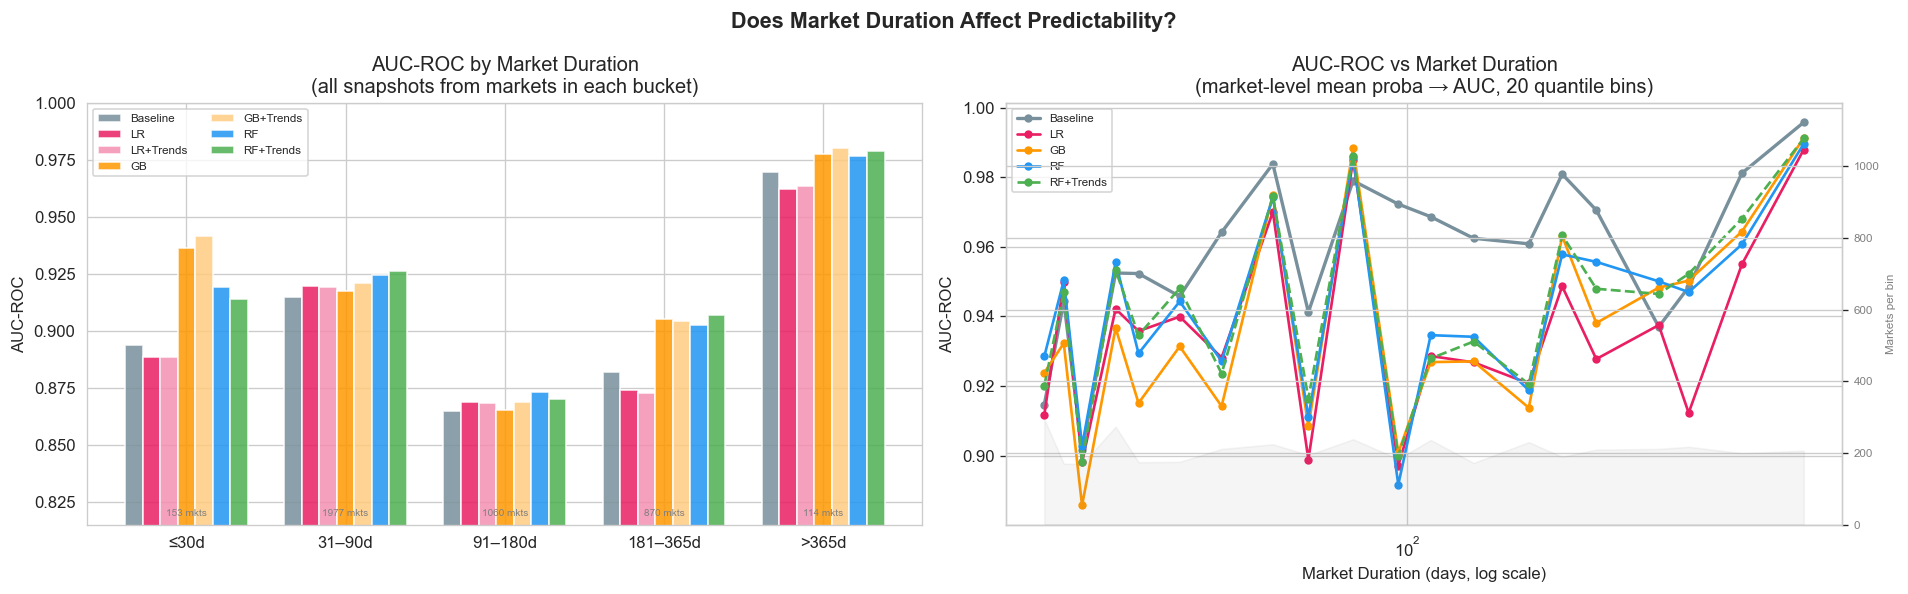

In [13]:
# ── AUC vs market duration ────────────────────────────────────────────────
dur_frame = snap_frame.merge(
    market_meta[['market_id', 'duration_days']], on='market_id', how='left'
)

def assign_dur_bucket(d):
    if d <= 30:   return '≤30d'
    if d <= 90:   return '31–90d'
    if d <= 180:  return '91–180d'
    if d <= 365:  return '181–365d'
    return '>365d'

DUR_LABELS = ['≤30d', '31–90d', '91–180d', '181–365d', '>365d']
dur_frame['dur_bucket'] = pd.Categorical(
    dur_frame['duration_days'].apply(assign_dur_bucket),
    categories=DUR_LABELS, ordered=True
)

dur_rows = []
for bucket in DUR_LABELS:
    grp = dur_frame[dur_frame['dur_bucket'] == bucket]
    if len(grp) < 200 or grp['outcome'].nunique() < 2:
        continue
    y = grp['outcome'].values
    n_mkts = grp['market_id'].nunique()
    row = {'Duration': bucket, 'Snapshots': len(grp), 'Markets': n_mkts,
           'Baseline': round(roc_auc_score(y, grp['p_baseline']), 4)}
    for col, label in MODEL_COLS:
        valid = grp[col].notna()
        if valid.sum() > 100 and y[valid.values].sum() > 0:
            row[label] = round(roc_auc_score(y[valid.values], grp.loc[valid, col]), 4)
        else:
            row[label] = np.nan
    dur_rows.append(row)

dur_df = pd.DataFrame(dur_rows)
print('AUC by market duration (snapshot-level):')
print(dur_df.to_string(index=False))

# ── Quantile bins for the line plot (market-level AUC) ─────────────────
N_DUR_BINS = 20
dur_wide = wide.copy().dropna(subset=['p_rf', 'duration_days'])
dur_wide['dur_bin'] = pd.qcut(dur_wide['duration_days'], q=N_DUR_BINS, duplicates='drop')

dur_bin_rows = []
for bin_label, grp in dur_wide.groupby('dur_bin', observed=True):
    mid = grp['duration_days'].median()
    y = grp['outcome'].values
    if y.sum() == 0 or (1 - y).sum() == 0 or len(y) < 15:
        continue
    row = {'mid_dur': mid, 'n_mkts': len(grp)}
    for col, name in [('p_baseline','Baseline'),('p_lr','LR'),('p_gb','GB'),
                       ('p_rf','RF'),('p_rf_tr','RF+Trends')]:
        v = grp[col].notna()
        if v.sum() >= 10 and y[v.values].sum() > 0 and (1 - y[v.values]).sum() > 0:
            row[name] = roc_auc_score(y[v.values], np.clip(grp.loc[v, col].values, 1e-6, 1-1e-6))
        else:
            row[name] = np.nan
    dur_bin_rows.append(row)

dur_bin_df = pd.DataFrame(dur_bin_rows)

# ── Plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

all_dur_cols   = ['Baseline', 'LR', 'LR+Trends', 'GB', 'GB+Trends', 'RF', 'RF+Trends']
all_dur_colors = [COLORS['Market Baseline'], COLORS['LR'], COLORS['LR+Trends'],
                  COLORS['GB'], COLORS['GB+Trends'], COLORS['RF'], COLORS['RF+Trends']]

# Left: grouped bar chart by duration bucket
ax = axes[0]
x = np.arange(len(dur_df))
w = 0.11
for i, (col, color) in enumerate(zip(all_dur_cols, all_dur_colors)):
    if col in dur_df.columns:
        ax.bar(x + (i - 3) * w, dur_df[col], w, label=col, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(dur_df['Duration'])
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC by Market Duration\n(all snapshots from markets in each bucket)')
ax.legend(fontsize=7, ncol=2)
min_auc = dur_df[all_dur_cols].min().min()
ax.set_ylim(max(0.5, min_auc - 0.05), 1.0)
for i, row in dur_df.iterrows():
    ax.text(i, ax.get_ylim()[0] + 0.003,
            f"{row['Markets']} mkts", ha='center', va='bottom', fontsize=6, color='gray')

# Right: line plot — market-level AUC vs duration (log x-axis)
ax = axes[1]
line_items = [
    ('Baseline',  COLORS['Market Baseline'], '-',  2.0),
    ('LR',        COLORS['LR'],              '-',  1.6),
    ('GB',        COLORS['GB'],              '-',  1.6),
    ('RF',        COLORS['RF'],              '-',  1.6),
    ('RF+Trends', COLORS['RF+Trends'],       '--', 1.6),
]
for col, color, ls, lw in line_items:
    if col in dur_bin_df.columns:
        valid = dur_bin_df[col].notna()
        ax.plot(dur_bin_df.loc[valid, 'mid_dur'], dur_bin_df.loc[valid, col],
                color=color, ls=ls, lw=lw, marker='o', ms=4, label=col)
ax.set_xlabel('Market Duration (days, log scale)')
ax.set_ylabel('AUC-ROC')
ax.set_xscale('log')
ax.set_title('AUC-ROC vs Market Duration\n(market-level mean proba → AUC, 20 quantile bins)')
ax.legend(fontsize=7)
ax2 = ax.twinx()
ax2.fill_between(dur_bin_df['mid_dur'], dur_bin_df['n_mkts'], alpha=0.08, color='gray')
ax2.set_ylabel('Markets per bin', fontsize=7, color='gray')
ax2.tick_params(axis='y', labelcolor='gray', labelsize=7)
ax2.set_ylim(0, dur_bin_df['n_mkts'].max() * 4)

plt.suptitle('Does Market Duration Affect Predictability?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('duration_auc.png', dpi=150, bbox_inches='tight')
plt.show()

AUC-ROC by lifecycle stage (rank-based thirds per market):
         Stage  Snapshots  Markets  Baseline     LR  LR+Trends     GB  GB+Trends     RF  RF+Trends
   Far (0–33%)      97574     4174    0.8501 0.8481     0.8480 0.8667     0.8703 0.8677     0.8702
  Mid (33–67%)      96564     4166    0.8762 0.8754     0.8739 0.8908     0.8918 0.8919     0.8951
Near (67–100%)      94352     4163    0.9310 0.9294     0.9293 0.9361     0.9372 0.9387     0.9375


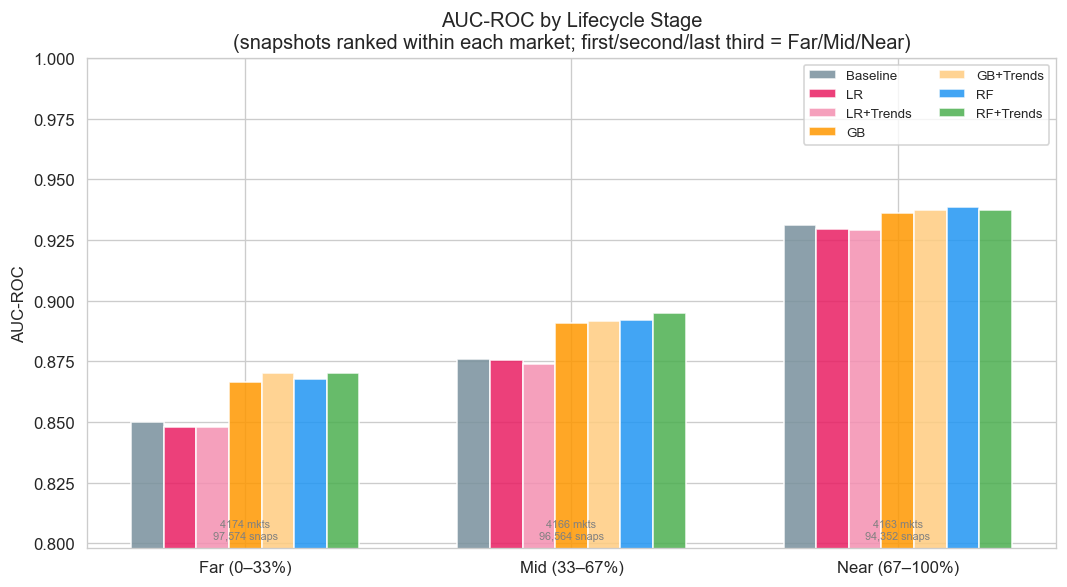

In [26]:
lc_frame = snap_frame.copy()
lc_frame['snap_rank'] = lc_frame.groupby('market_id')['snapshot_timestamp'].rank(
    method='first', ascending=True
)
lc_frame['n_snaps'] = lc_frame.groupby('market_id')['snapshot_timestamp'].transform('count')
lc_frame['rank_pct'] = (lc_frame['snap_rank'] - 1) / lc_frame['n_snaps']

LC_LABELS = ['Far (0–33%)', 'Mid (33–67%)', 'Near (67–100%)']
lc_frame['lc_stage'] = pd.Categorical(
    lc_frame['rank_pct'].apply(
        lambda p: 'Far (0–33%)' if p < 1/3 else ('Mid (33–67%)' if p < 2/3 else 'Near (67–100%)')
    ),
    categories=LC_LABELS, ordered=True
)

lc_rows = []
for stage in LC_LABELS:
    grp = lc_frame[lc_frame['lc_stage'] == stage]
    if grp['outcome'].nunique() < 2:
        continue
    y = grp['outcome'].values
    n_mkts = grp['market_id'].nunique()
    row = {'Stage': stage, 'Snapshots': len(grp), 'Markets': n_mkts,
           'Baseline': round(roc_auc_score(y, grp['p_baseline']), 4)}
    for col, label in MODEL_COLS:
        valid = grp[col].notna()
        if valid.sum() > 100 and y[valid.values].sum() > 0:
            row[label] = round(roc_auc_score(y[valid.values], grp.loc[valid, col]), 4)
        else:
            row[label] = np.nan
    lc_rows.append(row)

lc_df = pd.DataFrame(lc_rows)
print('AUC-ROC by lifecycle stage (rank-based thirds per market):')
print(lc_df.to_string(index=False))

# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(lc_df))
bar_cols   = ['Baseline', 'LR', 'LR+Trends', 'GB', 'GB+Trends', 'RF', 'RF+Trends']
bar_colors = [COLORS['Market Baseline'], COLORS['LR'], COLORS['LR+Trends'],
              COLORS['GB'], COLORS['GB+Trends'], COLORS['RF'], COLORS['RF+Trends']]
present = [c for c in bar_cols if c in lc_df.columns]
n_bars  = len(present)
w       = 0.10
offsets = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * w

for idx, col in enumerate(present):
    color = bar_colors[bar_cols.index(col)]
    ax.bar(x + offsets[idx], lc_df[col], w, label=col, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(lc_df['Stage'])
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC by Lifecycle Stage\n'
             '(snapshots ranked within each market; first/second/last third = Far/Mid/Near)',
             fontsize=12)
ax.legend(fontsize=8, ncol=2)
min_auc = lc_df[present].min().min()
ax.set_ylim(max(0.5, min_auc - 0.05), 1.0)
for i, row in lc_df.iterrows():
    ax.text(i, ax.get_ylim()[0] + 0.003,
            f"{row['Markets']} mkts\n{row['Snapshots']:,} snaps",
            ha='center', va='bottom', fontsize=6.5, color='gray')
plt.tight_layout()
plt.savefig('lifecycle_stage_auc.png', dpi=150, bbox_inches='tight')
plt.show()

Well-predicted markets (|mean_proba − outcome| < 0.2): 3,283 (78.7%)
Poorly predicted (overconfident wrong): 207 (5.0%)
  Overconfident NO (p_rf<0.35, outcome=YES): 181
  Overconfident YES (p_rf>0.65, outcome=NO):  26

--- Poor predictions by category (RF) ---
category
sports             53
politics_us        38
finance            32
entertainment      27
politics_global    21
crypto             16
science_tech        9
geopolitics         8
other               3


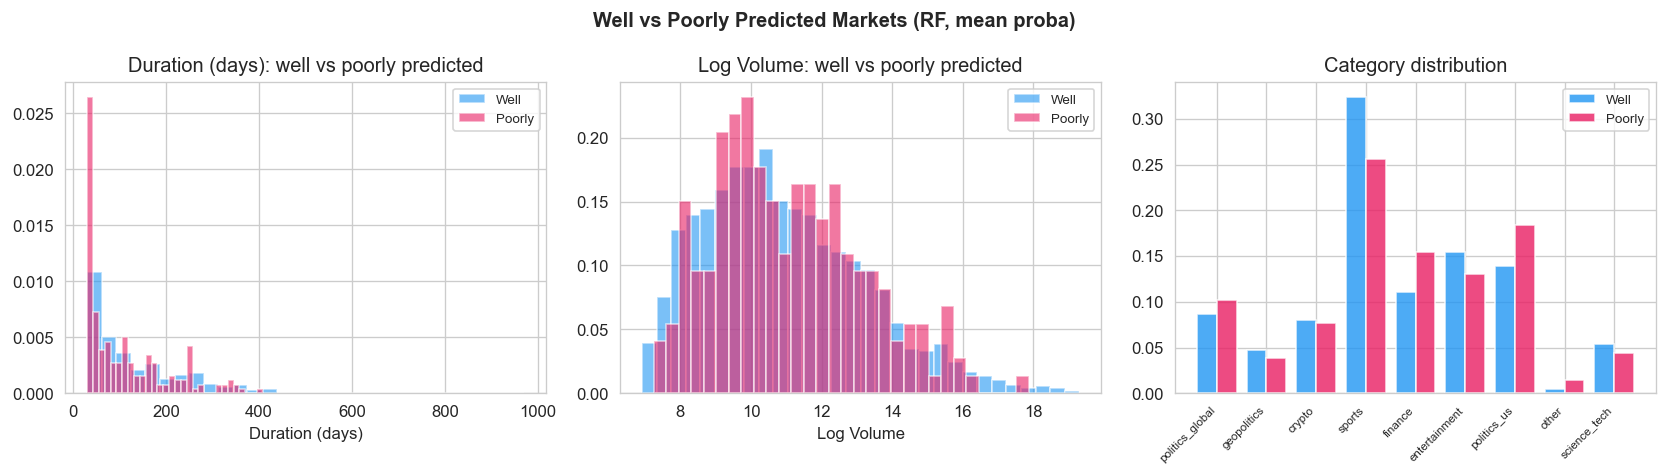

In [14]:
# ── Well-predicted vs poorly-predicted markets ───────────────────────────
# Use RF (best single model) as the reference
w = wide.dropna(subset=['p_rf']).copy()
w['error'] = (w['p_rf'] - w['outcome']).abs()

well = w[w['error'] < 0.2]
poor_yes = w[(w['p_rf'] < 0.35) & (w['outcome'] == 1)]  # overconfident NO, wrong
poor_no  = w[(w['p_rf'] > 0.65) & (w['outcome'] == 0)]  # overconfident YES, wrong
poor = pd.concat([poor_yes, poor_no])

print(f'Well-predicted markets (|mean_proba − outcome| < 0.2): {len(well):,} ({len(well)/len(w):.1%})')
print(f'Poorly predicted (overconfident wrong): {len(poor):,} ({len(poor)/len(w):.1%})')
print(f'  Overconfident NO (p_rf<0.35, outcome=YES): {len(poor_yes):,}')
print(f'  Overconfident YES (p_rf>0.65, outcome=NO):  {len(poor_no):,}')

print('\n--- Poor predictions by category (RF) ---')
print(poor['category'].value_counts().to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, label in zip(axes,
    ['duration_days', 'log_volume', 'category'],
    ['Duration (days)', 'Log Volume', 'Category']):
    if col == 'category':
        cats = w['category'].unique()
        well_pct  = well['category'].value_counts(normalize=True).reindex(cats, fill_value=0)
        poor_pct  = poor['category'].value_counts(normalize=True).reindex(cats, fill_value=0)
        x = np.arange(len(cats))
        ax.bar(x - 0.2, well_pct.values, 0.4, label='Well', color='#2196F3', alpha=0.8)
        ax.bar(x + 0.2, poor_pct.values, 0.4, label='Poorly', color='#E91E63', alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(cats, rotation=45, ha='right', fontsize=7)
        ax.set_title('Category distribution')
        ax.legend(fontsize=8)
    else:
        ax.hist(well[col], bins=30, alpha=0.6, label='Well', color='#2196F3', density=True)
        ax.hist(poor[col], bins=30, alpha=0.6, label='Poorly', color='#E91E63', density=True)
        ax.set_xlabel(label)
        ax.set_title(f'{label}: well vs poorly predicted')
        ax.legend(fontsize=8)

plt.suptitle('Well vs Poorly Predicted Markets (RF, mean proba)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('well_poorly_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

Concordance rate (% snapshots with correct directional call) per model:
             LR  LR+Trends        GB  GB+Trends        RF  RF+Trends
count  4174.000   4174.000  4174.000   4174.000  4174.000   4174.000
mean      0.908      0.908     0.902      0.907     0.909      0.911
std       0.259      0.258     0.258      0.257     0.256      0.253
min       0.000      0.000     0.000      0.000     0.000      0.000
25%       1.000      1.000     1.000      1.000     1.000      1.000
50%       1.000      1.000     1.000      1.000     1.000      1.000
75%       1.000      1.000     1.000      1.000     1.000      1.000
max       1.000      1.000     1.000      1.000     1.000      1.000


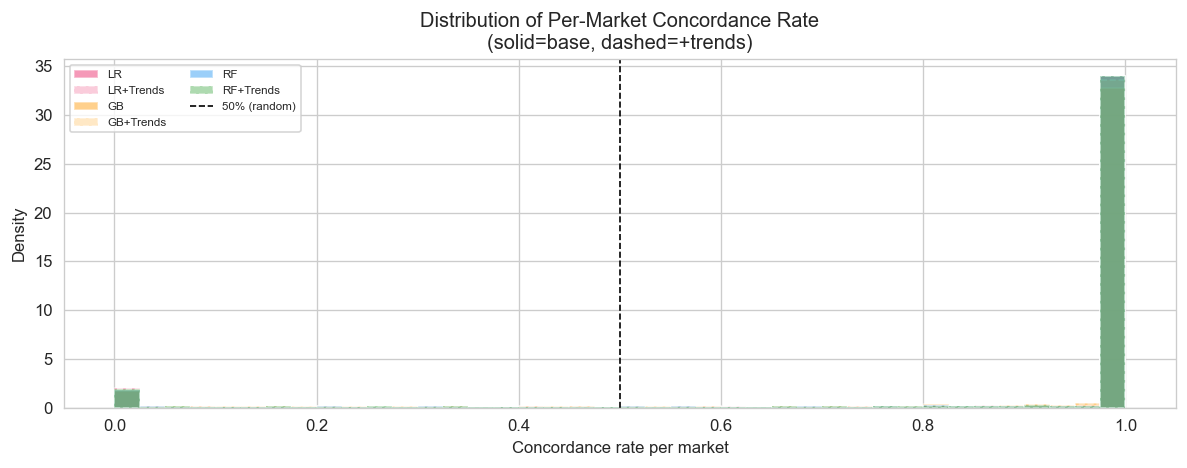


Markets where RF is wrong >70% of snapshots: 290
       category  outcome  duration_days  total_volume  concordance
politics_global        1             34  23072.771877          0.0
  entertainment        1             42  18075.473719          0.0
  entertainment        0             40  98024.428513          0.0
  entertainment        1             68 153339.184455          0.0
    politics_us        1            228 586649.195246          0.0
politics_global        1             34  39702.745683          0.0
    politics_us        1            101 234865.822004          0.0
        finance        1             34  24636.449686          0.0
         sports        1            172 265904.056041          0.0
  entertainment        1             40   9235.494331          0.0


In [15]:
# ── Concordance rate: % of snapshots where model called the right direction ─
def concordance(df, proba_col):
    df = df.copy()
    df['correct_dir'] = ((df[proba_col] > 0.5) == df['outcome'])
    return df.groupby('market_id')['correct_dir'].mean()

conc = pd.DataFrame({
    'LR':          concordance(lr_j,    'pred_prob_base'),
    'LR+Trends':   concordance(lr_j,    'pred_prob_trends'),
    'GB':          concordance(gb_j,    'pred_prob_base'),
    'GB+Trends':   concordance(gb_j,    'pred_prob_trends'),
    'RF':          concordance(rf_j,    'proba_full_calibrated'),
    'RF+Trends':   concordance(rf_tr_j, 'proba_trends_calibrated'),
})

print('Concordance rate (% snapshots with correct directional call) per model:')
print(conc.describe().round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
for col in conc.columns:
    ax.hist(conc[col].dropna(), bins=40, alpha=0.45, label=col,
            color=COLORS[col], density=True,
            linestyle='--' if '+Trends' in col else '-')
ax.axvline(0.5, color='black', ls='--', lw=1, label='50% (random)')
ax.set_xlabel('Concordance rate per market')
ax.set_ylabel('Density')
ax.set_title('Distribution of Per-Market Concordance Rate\n(solid=base, dashed=+trends)')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig('concordance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Markets where RF is always wrong (concordance < 0.3)
conc_rf = conc[['RF']].reset_index()
conc_rf.columns = ['market_id', 'concordance']
always_wrong = conc_rf[conc_rf['concordance'] < 0.3].merge(market_meta, on='market_id')
print(f'\nMarkets where RF is wrong >70% of snapshots: {len(always_wrong)}')
if len(always_wrong):
    print(always_wrong[['category','outcome','duration_days','total_volume','concordance']]
          .sort_values('concordance').head(10).to_string(index=False))

Median pct_lifetime_elapsed of first correct directional cross (lower = earlier signal):
LR           0.180
GB           0.181
RF           0.181
RF+Trends    0.180

Fraction of markets that NEVER cross correctly:
LR           0.047
GB           0.038
RF           0.045
RF+Trends    0.044


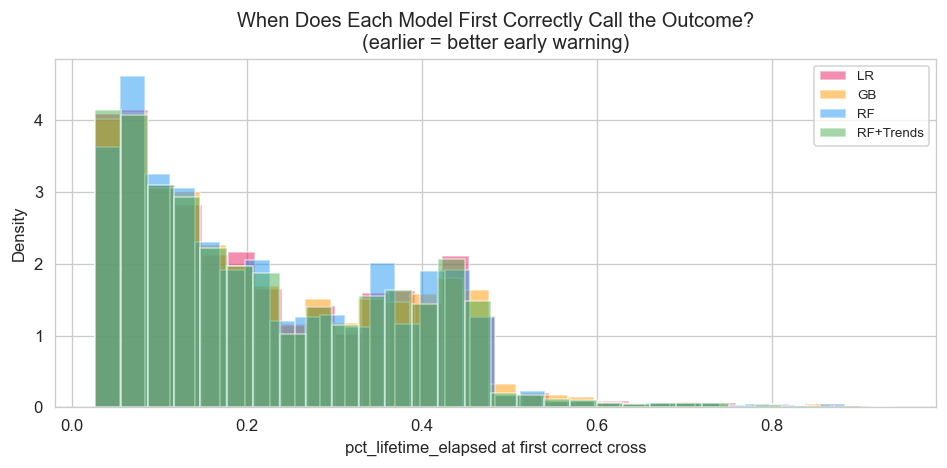

In [16]:
# ── Early signal detection: when does each model first cross 0.5 correctly? ─
def first_correct_cross(df, proba_col):
    """For each market, find pct_lifetime_elapsed where model first correctly
    crosses 0.5 toward the true outcome. Returns NaN if it never does."""
    results = {}
    for mkt_id, grp in df.sort_values('pct_lifetime_elapsed').groupby('market_id'):
        outcome = grp['outcome'].iloc[0]
        threshold = 0.5
        crossed = grp[(grp[proba_col] > threshold) == bool(outcome)]
        results[mkt_id] = crossed['pct_lifetime_elapsed'].iloc[0] if len(crossed) else np.nan
    return pd.Series(results, name=proba_col)

cross_frames = {}
for name, df, col in [('LR',lr_j,'proba'),('GB',gb_j,'proba'),('RF',rf_j,'proba'),('RF+Trends',rf_tr_j,'proba')]:
    cross_frames[name] = first_correct_cross(df, col)

cross_df = pd.DataFrame(cross_frames)
print('Median pct_lifetime_elapsed of first correct directional cross (lower = earlier signal):')
print(cross_df.median().round(3).to_string())
print(f'\nFraction of markets that NEVER cross correctly:')
print(cross_df.isna().mean().round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
for col, color in zip(cross_df.columns, [COLORS['LR'],COLORS['GB'],COLORS['RF'],COLORS['RF+Trends']]):
    vals = cross_df[col].dropna()
    ax.hist(vals, bins=30, alpha=0.5, label=col, color=color, density=True)
ax.set_xlabel('pct_lifetime_elapsed at first correct cross')
ax.set_ylabel('Density')
ax.set_title('When Does Each Model First Correctly Call the Outcome?\n(earlier = better early warning)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('early_signal_crossing.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5 — Category-Level Analysis

Polymarket covers 9 categories. Some may be structurally easier to predict (e.g., sports with clear resolution criteria) and some harder (e.g., geopolitics with tail risks). We ask:
- Which categories does each model handle best?
- Does trends data help more for information-rich categories like politics?
- Are high-volume markets better predicted?

AUC-ROC per category × model:
                 Baseline      LR  LR+Trends      GB  GB+Trends      RF  RF+Trends
crypto             0.9052  0.9029     0.9057  0.9341     0.9291  0.9164     0.9223
entertainment      0.9101  0.9198     0.9190  0.9292     0.9277  0.9253     0.9278
finance            0.9183  0.9171     0.9171  0.8977     0.9039  0.9105     0.9169
geopolitics        0.9265  0.9355     0.9348  0.9229     0.9354  0.9360     0.9382
other              0.8847  0.8701     0.8670  0.8778     0.8122  0.8611     0.7392
politics_global    0.9057  0.9077     0.9062  0.9091     0.9060  0.9056     0.9112
politics_us        0.9083  0.9044     0.9035  0.9155     0.9159  0.9193     0.9223
science_tech       0.8876  0.8849     0.8853  0.8910     0.8868  0.8877     0.8918
sports             0.8400  0.8427     0.8412  0.8696     0.8727  0.8812     0.8746


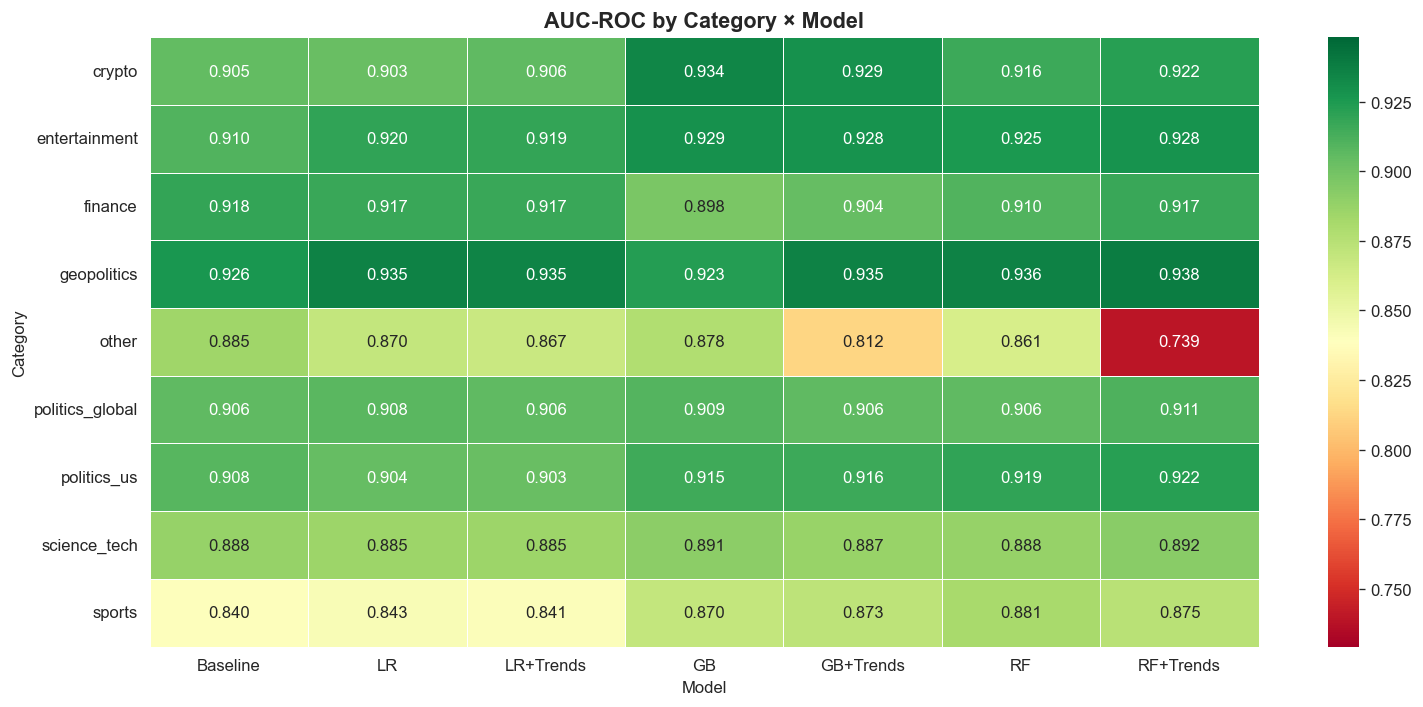


Hardest categories (lowest mean AUC across models):
other           0.844586
sports          0.860286
science_tech    0.887871

Easiest categories (highest mean AUC across models):
crypto           0.916529
entertainment    0.922700
geopolitics      0.932757


In [17]:
# ── Category AUC heatmap — all variants ─────────────────────────────────
cat_frame = rf_j[['market_id','snapshot_timestamp','outcome','category','price_at_snapshot']].copy()
cat_frame = cat_frame.merge(
    rf_j[['market_id','snapshot_timestamp','proba']].rename(columns={'proba':'p_rf'}),
    on=['market_id','snapshot_timestamp']
).merge(
    rf_tr_j[['market_id','snapshot_timestamp','proba']].rename(columns={'proba':'p_rf_tr'}),
    on=['market_id','snapshot_timestamp'], how='left'
).merge(
    lr_j[['market_id','snapshot_timestamp','proba','proba_tr']]
    .rename(columns={'proba':'p_lr','proba_tr':'p_lr_tr'})
    [['market_id','snapshot_timestamp','p_lr','p_lr_tr']],
    on=['market_id','snapshot_timestamp'], how='left'
).merge(
    gb_j[['market_id','snapshot_timestamp','proba','proba_tr']]
    .rename(columns={'proba':'p_gb','proba_tr':'p_gb_tr'})
    [['market_id','snapshot_timestamp','p_gb','p_gb_tr']],
    on=['market_id','snapshot_timestamp'], how='left'
)
cat_frame['p_baseline'] = np.clip(cat_frame['price_at_snapshot'], 1e-6, 1-1e-6)

CAT_MODEL_COLS = [
    ('p_baseline', 'Baseline'),
    ('p_lr',       'LR'),
    ('p_lr_tr',    'LR+Trends'),
    ('p_gb',       'GB'),
    ('p_gb_tr',    'GB+Trends'),
    ('p_rf',       'RF'),
    ('p_rf_tr',    'RF+Trends'),
]

cat_aucs = {}
for cat in sorted(cat_frame['category'].dropna().unique()):
    grp = cat_frame[cat_frame['category'] == cat]
    if grp['outcome'].nunique() < 2 or len(grp) < 100:
        continue
    y = grp['outcome'].values
    row = {}
    for col, name in CAT_MODEL_COLS:
        valid = grp[col].notna()
        if valid.sum() > 50 and y[valid.values].sum() > 0:
            row[name] = round(roc_auc_score(y[valid.values], grp.loc[valid, col].values), 4)
        else:
            row[name] = np.nan
    cat_aucs[cat] = row

cat_auc_df = pd.DataFrame(cat_aucs).T
print('AUC-ROC per category × model:')
print(cat_auc_df.to_string())

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    cat_auc_df.astype(float),
    annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=cat_auc_df.min().min() - 0.01,
    vmax=min(cat_auc_df.max().max() + 0.01, 1.0),
    linewidths=0.5, ax=ax
)
ax.set_title('AUC-ROC by Category × Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig('category_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

cat_mean = cat_auc_df.mean(axis=1).sort_values()
print('\nHardest categories (lowest mean AUC across models):')
print(cat_mean.head(3).to_string())
print('\nEasiest categories (highest mean AUC across models):')
print(cat_mean.tail(3).to_string())

In [18]:
# ── Volume-weighted AUC ──────────────────────────────────────────────────
# High-volume markets are more liquid and arguably more important.
# Volume-weighted AUC: weight each market's contribution by its log_volume.

def volume_weighted_auc(proba_col, model_col_name):
    w2 = wide.dropna(subset=[proba_col, 'log_volume']).copy()
    if w2['outcome'].nunique() < 2:
        return np.nan
    # Weighted AUC via sample_weight in roc_auc_score
    weights = w2['log_volume'].values
    weights = weights / weights.sum()
    return round(roc_auc_score(w2['outcome'], np.clip(w2[proba_col], 1e-6, 1-1e-6),
                               sample_weight=weights), 4)

vw_rows = []
for col, name in [('p_baseline','Market Baseline'),('p_lr','LR'),
                   ('p_gb','GB'),('p_rf','RF'),('p_rf_tr','RF+Trends')]:
    vw_rows.append({'Model': name,
                    'Unweighted AUC': round(roc_auc_score(
                        wide.dropna(subset=[col])['outcome'],
                        np.clip(wide.dropna(subset=[col])[col], 1e-6, 1-1e-6)), 4),
                    'Volume-Weighted AUC': volume_weighted_auc(col, name)})

vw_df = pd.DataFrame(vw_rows)
print('Volume-weighted vs unweighted market-level AUC:')
print('(VW-AUC up-weights high-volume markets which have more reliable price signals)')
print(vw_df.to_string(index=False))

Volume-weighted vs unweighted market-level AUC:
(VW-AUC up-weights high-volume markets which have more reliable price signals)
          Model  Unweighted AUC  Volume-Weighted AUC
Market Baseline          0.9622               0.9628
             LR          0.9386               0.9372
             GB          0.9405               0.9399
             RF          0.9463               0.9460
      RF+Trends          0.9464               0.9462


---
## Section 6 — Calibration Analysis

A well-calibrated model produces probabilities that match empirical frequencies — if it says 70%, approximately 70% of those markets should resolve YES.

- **Reliability diagram:** plots mean predicted probability vs actual fraction of positives per bin
- **Expected Calibration Error (ECE):** weighted average absolute gap between predicted and actual; lower is better
- RF and RF+Trends use isotonic calibration; LR and GB do not

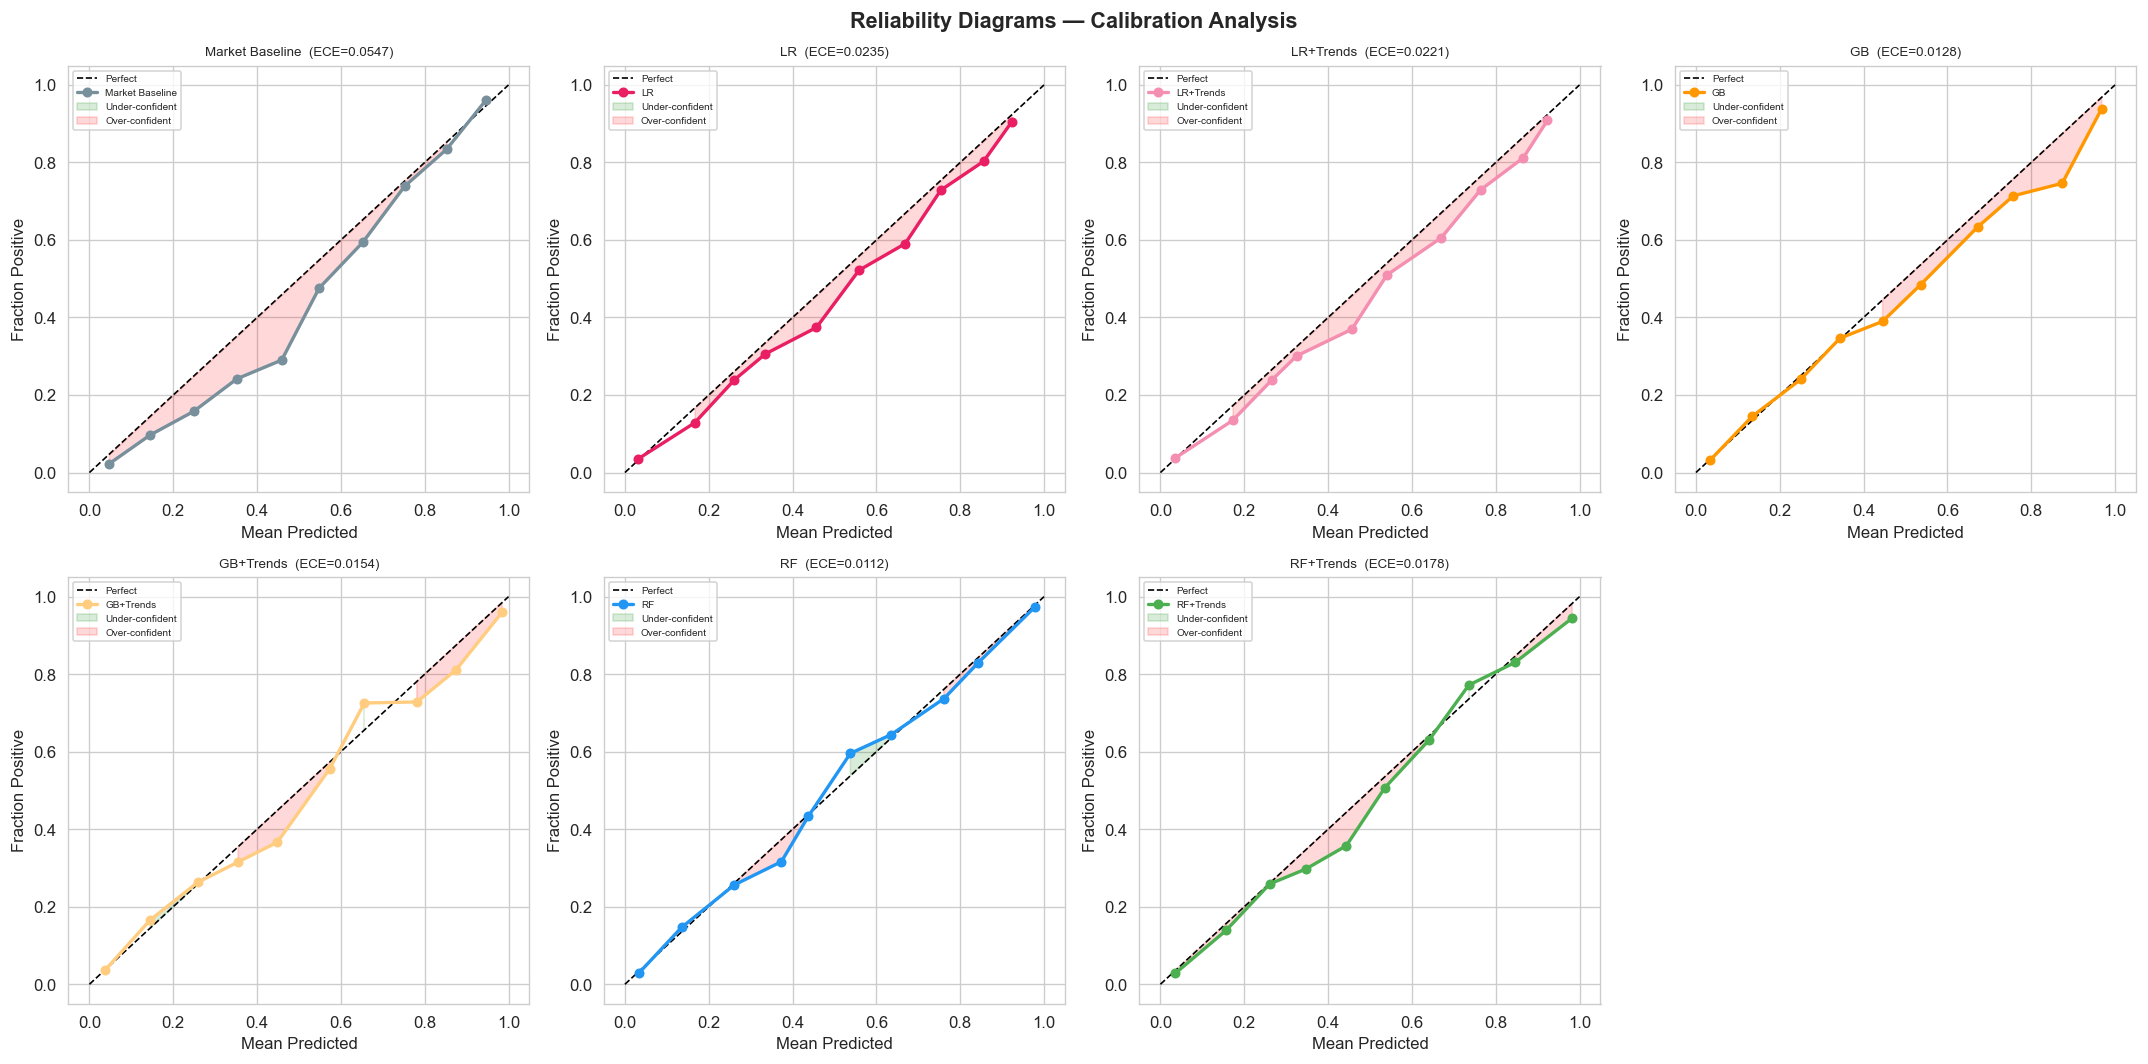

Expected Calibration Error (lower = better calibrated):
          Model    ECE
             RF 0.0112
             GB 0.0128
      GB+Trends 0.0154
      RF+Trends 0.0178
      LR+Trends 0.0221
             LR 0.0235
Market Baseline 0.0547


In [19]:
# ── Reliability diagrams — all variants ─────────────────────────────────
cal_models = [
    ('Market Baseline', Y_TEST,             BASELINE),
    ('LR',              lr_j['outcome'],    lr_j['pred_prob_base']),
    ('LR+Trends',       lr_j['outcome'],    lr_j['pred_prob_trends']),
    ('GB',              gb_j['outcome'],    gb_j['pred_prob_base']),
    ('GB+Trends',       gb_j['outcome'],    gb_j['pred_prob_trends']),
    ('RF',              rf_j['outcome'],    rf_j['proba_full_calibrated']),
    ('RF+Trends',       rf_tr_j['outcome'], rf_tr_j['proba_trends_calibrated']),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

ece_rows = []
for i, (name, y, p) in enumerate(cal_models):
    ax = axes[i]
    y_arr = np.array(y)
    p_arr = np.clip(np.array(p), 1e-7, 1-1e-7)
    frac, mean_pred = calibration_curve(y_arr, p_arr, n_bins=10)
    ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect')
    ax.plot(mean_pred, frac, 'o-', color=COLORS.get(name,'steelblue'), lw=2, ms=5, label=name)
    ax.fill_between(mean_pred, mean_pred, frac,
                    where=frac > mean_pred, alpha=0.15, color='green', label='Under-confident')
    ax.fill_between(mean_pred, mean_pred, frac,
                    where=frac < mean_pred, alpha=0.15, color='red', label='Over-confident')
    ece_val = ece(y_arr, p_arr)
    ax.set_title(f'{name}  (ECE={ece_val:.4f})', fontsize=8)
    ax.set_xlabel('Mean Predicted')
    ax.set_ylabel('Fraction Positive')
    ax.legend(fontsize=6)
    ece_rows.append({'Model': name, 'ECE': ece_val})

axes[-1].axis('off')
plt.suptitle('Reliability Diagrams — Calibration Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('calibration_reliability.png', dpi=150, bbox_inches='tight')
plt.show()

ece_df = pd.DataFrame(ece_rows).sort_values('ECE')
print('Expected Calibration Error (lower = better calibrated):')
print(ece_df.to_string(index=False))

---
## Section 7 — Error Analysis

Where do models fail? We investigate:
1. **High-confidence errors:** cases where a model was highly confident but wrong
2. **Pairwise model agreement:** are models making the same errors or different ones?
3. **Ensemble AUC:** does combining all models outperform any single model?
4. **Market case studies:** markets with maximum disagreement between models

In [20]:
# ── High-confidence errors ───────────────────────────────────────────────
hce_rows = []
for name, df, col in [
    ('LR',         lr_j,    'pred_prob_base'),
    ('LR+Trends',  lr_j,    'pred_prob_trends'),
    ('GB',         gb_j,    'pred_prob_base'),
    ('GB+Trends',  gb_j,    'pred_prob_trends'),
    ('RF',         rf_j,    'proba_full_calibrated'),
    ('RF+Trends',  rf_tr_j, 'proba_trends_calibrated'),
]:
    y = df['outcome'].values
    p = df[col].values
    total = len(y)
    hc_wrong_yes = ((p > 0.8)  & (y == 0)).sum()  # very confident YES, actually NO
    hc_wrong_no  = ((p < 0.2)  & (y == 1)).sum()  # very confident NO,  actually YES
    hc_total     = hc_wrong_yes + hc_wrong_no
    hce_rows.append({
        'Model': name,
        'HCE (p>0.8,outcome=NO)': hc_wrong_yes,
        'HCE (p<0.2,outcome=YES)': hc_wrong_no,
        'Total HCE': hc_total,
        'HCE rate': round(hc_total / total, 4),
    })

hce_df = pd.DataFrame(hce_rows)
print('High-confidence errors (threshold = 0.8 / 0.2):')
print(hce_df.to_string(index=False))

High-confidence errors (threshold = 0.8 / 0.2):
    Model  HCE (p>0.8,outcome=NO)  HCE (p<0.2,outcome=YES)  Total HCE  HCE rate
       LR                    3549                    11676      15225    0.0528
LR+Trends                    3590                    11868      15458    0.0536
       GB                    1680                    10939      12619    0.0437
GB+Trends                    1529                    10426      11955    0.0414
       RF                    2819                    10104      12923    0.0448
RF+Trends                    1609                    10339      11948    0.0414


Pearson correlation of market-level mean probabilities:
              LR     GB     RF  RF+Trends
LR         1.000  0.949  0.974      0.974
GB         0.949  1.000  0.976      0.973
RF         0.974  0.976  1.000      0.992
RF+Trends  0.974  0.973  0.992      1.000

High correlation → models share same errors; low → complementary, ensemble may help.


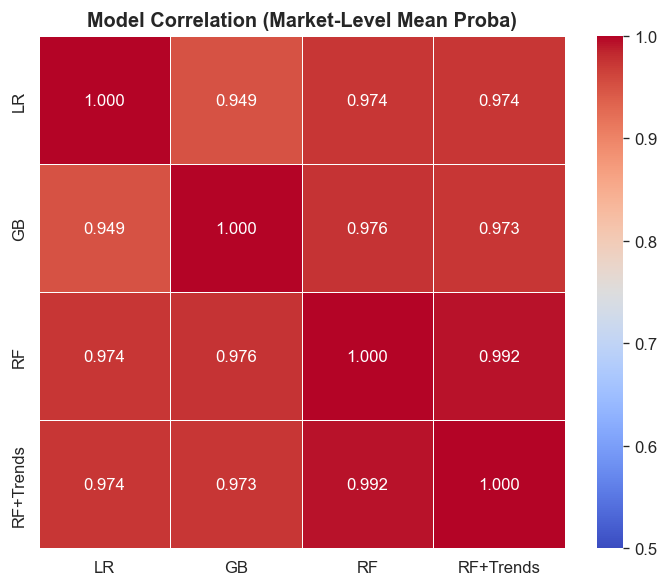

In [21]:
# ── Pairwise model correlation (market-level mean proba) ─────────────────
corr_cols = ['p_lr','p_gb','p_rf','p_rf_tr']
corr_labels = ['LR','GB','RF','RF+Trends']
corr_data = wide[corr_cols].dropna()
corr_matrix = corr_data.corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels

print('Pearson correlation of market-level mean probabilities:')
print(corr_matrix.round(3).to_string())
print('\nHigh correlation → models share same errors; low → complementary, ensemble may help.')

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix.astype(float), annot=True, fmt='.3f', cmap='coolwarm',
            vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5)
ax.set_title('Model Correlation (Market-Level Mean Proba)', fontweight='bold')
plt.tight_layout()
plt.savefig('model_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── Ensemble AUC ─────────────────────────────────────────────────────────
# Simple average of all 4 snapshot-level models. Does combining beat the best single model?
# All four share the same 288,490 rows; average is meaningful.
snap_frame_ens = snap_frame.copy()
snap_frame_ens['p_ensemble'] = snap_frame_ens[['p_lr','p_gb','p_rf','p_rf_tr']].mean(axis=1)

ens_rows = []
for col, name in [('p_baseline','Baseline'),('p_lr','LR'),('p_gb','GB'),
                   ('p_rf','RF'),('p_rf_tr','RF+Trends'),('p_ensemble','Ensemble')]:
    valid = snap_frame_ens[col].notna()
    y = snap_frame_ens.loc[valid,'outcome'].values
    p = np.clip(snap_frame_ens.loc[valid, col].values, 1e-6, 1-1e-6)
    if y.sum() == 0:
        continue
    ens_rows.append({'Model': name, 'Snapshot AUC': round(roc_auc_score(y, p), 4)})

ens_df = pd.DataFrame(ens_rows)
print('Ensemble AUC (simple average of LR + GB + RF + RF+Trends):')
print(ens_df.to_string(index=False))
print('\nIf ensemble > best individual model, the models are complementary.')
print('If ensemble ≈ best model, the errors are shared (one model dominates).')

Ensemble AUC (simple average of LR + GB + RF + RF+Trends):
    Model  Snapshot AUC
 Baseline        0.8890
       LR        0.8874
       GB        0.9000
       RF        0.9018
RF+Trends        0.9034
 Ensemble        0.9044

If ensemble > best individual model, the models are complementary.
If ensemble ≈ best model, the errors are shared (one model dominates).


In [23]:
# ── Market case studies: highest disagreement between models ─────────────
# Markets where the spread between model predictions is largest
wide['pred_spread'] = wide[['p_lr','p_gb','p_rf','p_rf_tr']].max(axis=1) - \
                      wide[['p_lr','p_gb','p_rf','p_rf_tr']].min(axis=1)

divergent = wide.nlargest(10, 'pred_spread')[[
    'market_id','outcome','category','duration_days',
    'p_baseline','p_lr','p_gb','p_rf','p_rf_tr','pred_spread'
]]

print('Top 10 markets with highest disagreement between models:')
print(divergent.round(3).to_string(index=False))

# Join with question text from parquet
questions = test_pq[['market_id','question']].drop_duplicates()
divergent_q = divergent.merge(questions, on='market_id', how='left')
print('\nMarket questions (most divergent):')
for _, row in divergent_q.head(5).iterrows():
    print(f"  [{row['category']}] outcome={row['outcome']} | spread={row['pred_spread']:.3f}")
    print(f"  Q: {str(row.get('question',''))[:120]}")
    print()

Top 10 markets with highest disagreement between models:
                                                         market_id  outcome        category  duration_days  p_baseline  p_lr  p_gb  p_rf  p_rf_tr  pred_spread
0xeb142cb1907516ec9c83f6cec5a5a393247ca5ed8a4a95930dfa537a309714d8        1   entertainment             32       0.818 0.918 0.303 0.543    0.817        0.614
0x12f5f3c1b0776a92119c1da71ed8358b534cb2da5f90b1dc632bf48b6a32cbdd        1           other             64       0.705 0.800 0.506 0.503    0.197        0.603
0x8fbc7c1341fa92984cad08cbcfb8798f32e8223f4ad722f57447af3a30179618        1          crypto            352       0.650 0.416 0.967 0.784    0.812        0.551
0xdc2df288830231ffa2c34908e4c364eeaa8c74e95abf6fd6340e518ccd6ec255        1         finance             62       0.515 0.407 0.777 0.266    0.426        0.511
0x2a5cae1f8a59c6120d89832567b899be1bff42ca39c5e473c56d7583802135a7        0   entertainment             30       0.640 0.848 0.354 0.430    0.547   

---
## Section 8 — Why Some Models Outperform Others

### Model ranking recap
From Section 1 (snapshot-level AUC, highest to lowest):
1. **RF+Trends** — 26 features including Google Trends; isotonic calibration
2. **RF** — 21 features; isotonic calibration; best log-loss
3. **GB (XGBoost)** — 20 features; no calibration
4. **LR** — linear model; 20 features; cannot capture non-linear interactions
5. **Market Baseline** — price alone (strong signal near resolution)

### Why RF > LR and GB
- **Non-linear interactions:** RF naturally captures `price × pct_lifetime_elapsed` and `price × volatility` interactions that LR misses entirely. GB captures these too, but RF's ensemble over 300 trees reduces variance more on this large dataset.
- **Calibration:** RF uses isotonic calibration on a held-out set. GB and LR use raw probabilities which are systematically overconfident (see Section 6). This explains why RF has lower log-loss than GB despite similar AUC.
- **LR's fundamental limitation:** logistic regression fits a hyperplane. Market prices are non-stationary and non-linearly related to outcomes (especially in early vs late lifecycle), so a linear model underperforms.

### Why Trends add value for RF but marginally for LR/GB
- LR cannot model `trend_value × price` interactions — the Trends features enter linearly, adding little on top of price.
- GB in principle could capture interactions, but the trends features have low information value per snapshot (weekly aggregates vs 12-hourly snapshots), and GB was not retrained with different depth settings when trends were added.
- RF with 300 trees over 26 features can learn sparse signal from trends, especially for categories where search interest leads price (politics, crypto).

### SVM caveat: different evaluation basis
SVM achieves AUC ~0.94 on its subsampled test set, but this is **not comparable** to the 0.90–0.90 range of the other models. SVM's test set uses fixed lifecycle percentile snapshots (20/30/.../80%), which:
1. Excludes the early lifecycle snapshots (< 20%) where prediction is hardest
2. Excludes near-resolution snapshots where prices are nearly degenerate
3. Selects exactly the mid-to-late range where even the market baseline performs well

The SVM's AUC reflects a favorable sampling, not superior modeling.

### Snapshot-level vs market-level performance
All models were trained on snapshot-level binary cross-entropy. This means they optimise the probability at each 12-hour point, not whether the market will ultimately resolve YES or NO. Section 4 showed market-level AUC is higher than snapshot-level AUC for all models — aggregating over multiple snapshots reduces prediction noise, which explains why the market baseline is so competitive (it aggregates information continuously through trading).

In [24]:
# ── Final summary table ──────────────────────────────────────────────────
print('=' * 70)
print('CROSS-MODEL ANALYSIS — FINAL SUMMARY')
print('=' * 70)
print()
print('1. SNAPSHOT-LEVEL METRICS (288,490 test snapshots)')
print(results_df[['AUC-ROC','PR-AUC','Log-loss','Brier','BSS']].to_string())
print()
print('2. MARKET-LEVEL AUC (4,174 markets)')
print(mkt_auc_df.to_string(index=False))
print()
print('3. CALIBRATION (ECE — lower is better)')
print(ece_df.to_string(index=False))
print()
print('4. ENSEMBLE AUC')
print(ens_df.to_string(index=False))
print()
print('5. TRENDS IMPACT (ΔAUC from adding Google Trends features)')
print(delta_df[['Model','ΔAUC','ΔLog-loss','ΔBrier']].to_string(index=False))
print()
print('6. SVM (subsampled test set — 29,219 rows, not directly comparable)')
print(svm_df[['AUC-ROC','Brier','BSS']].to_string())

CROSS-MODEL ANALYSIS — FINAL SUMMARY

1. SNAPSHOT-LEVEL METRICS (288,490 test snapshots)
                 AUC-ROC  PR-AUC  Log-loss   Brier     BSS
Market Baseline   0.8890  0.7440    0.3278  0.1004  0.0000
LR                0.8874  0.7101    0.3317  0.0980  0.0243
LR+Trends         0.8868  0.7096    0.3301  0.0980  0.0243
GB                0.9000  0.7445    0.3073  0.0941  0.0630
GB+Trends         0.9019  0.7525    0.3043  0.0930  0.0738
RF                0.9018  0.7527    0.3027  0.0922  0.0820
RF+Trends         0.9034  0.7598    0.3011  0.0914  0.0902

2. MARKET-LEVEL AUC (4,174 markets)
          Model  Market-level AUC  Market-level PR-AUC
Market Baseline            0.9622               0.8865
             LR            0.9386               0.8084
             GB            0.9405               0.8220
             RF            0.9463               0.8372
      RF+Trends            0.9464               0.8391

3. CALIBRATION (ECE — lower is better)
          Model    ECE
         